In [ ]:
import pandas as pd
import numpy as np
import sqlite3
import requests

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer

NumPy for numerical computations ,Pandas was used for data manipulation, Matplotlib for creating graphical representations, and Seaborn for generating advanced statistical visualizations. These libraries provide the foundation for preprocessing, analyzing, and interpreting the dataset effectively.

SimpleImputer and KNNImputer were used to address missing data through statistical and machine learning-based techniques. The zscore function was utilized to detect outliers, while winsorize was applied to limit the effect of extreme values. These preprocessing steps improve data quality, enhance model performance, and ensure reliable analytical results.

This code imports all the Python libraries required for the project. These libraries provide functions for data manipulation, visualization, database connectivity, API handling, and data preprocessing. Importing libraries at the beginning keeps the project organized and ensures that all necessary tools are available before working with the dataset.

Why this cell is used:
To make all required packages available for the entire project.

Outcome:
All libraries are successfully loaded into the notebook.

In [ ]:
customers = pd.read_csv("/content/customers - customers.csv.csv")

customers.head()

,customer_id,name,age,gender,city,income
0,101,Aarav,24,Male,Mumbai,45000
1,102,Diya,30,Female,Delhi,55000
2,103,Kabir,27,Male,Bangalore,48000
3,104,Meera,35,Female,Ahmedabad,60000
4,105,Vivaan,40,Male,Pune,75000


This code reads the customer dataset from a CSV file using Pandas. After loading the data, the first five records are displayed to verify that the dataset has been imported correctly and to understand its structure.

Why this cell is used:
To import customer information into the project for further preprocessing and analysis.

Outcome:
The customer dataset is stored in a DataFrame named customers.

In [ ]:
transactions = pd.read_json("/content/transactions.json")

transactions.head()

,transaction_id,customer_id,product_id,amount,payment_mode,date
0,T001,101,P001,499,UPI,2025-10-01
1,T002,103,P003,1299,Credit Card,2025-10-02
2,T003,104,P002,699,Debit Card,2025-10-03
3,T004,105,P005,1999,UPI,2025-10-05
4,T005,107,P004,899,Cash,2025-10-07



This code imports transaction data from a JSON file. Displaying the first few rows helps verify that the JSON file has been read successfully and provides an overview of the transaction records.

Why this cell is used:
To include customer transaction details in the project.

Outcome:
Transaction data is loaded into the transactions DataFrame.

In [ ]:
with open('/content/products (1).sql', 'r') as f:
    sql_content = f.read()
print(sql_content)

-- products.sql
-- SQL script to create 'products' table and insert sample product rows

DROP TABLE IF EXISTS products;

CREATE TABLE products (
    product_id TEXT PRIMARY KEY,
    product_name TEXT NOT NULL,
    category TEXT,
    price INTEGER,
    stock INTEGER
);

INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P001', 'Earphones', 'Electronics', 499, 50);
INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P002', 'Bluetooth Speaker', 'Audio', 699, 40);
INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P003', 'Smart Watch', 'Wearable', 1299, 25);
INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P004', 'Keyboard', 'Computer', 899, 60);
INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P005', 'Headphones', 'Audio', 1999, 30);
INSERT INTO products (product_id, product_name, category, price, stock) VALUES ('P006', 'Power Bank', 'Mob


This code used to opens the SQL file containing product information and reads its contents. Printing the SQL script allows the user to verify that the database creation commands have been loaded correctly.

Why this cell is used:
To prepare product data stored in SQL format for database execution.

Outcome:
The SQL script is successfully loaded into memory.

In [ ]:
conn = sqlite3.connect(':memory:') # Create an in-memory SQLite database
conn.executescript(sql_content) # Execute the SQL script to create and populate the table

products = pd.read_sql("SELECT * FROM products", conn)

products.head()

conn.close()


This code creates a temporary SQLite database, executes the SQL script, and retrieves the product table into a Pandas DataFrame. After loading the data, the database connection is closed to free system resources.

Why this cell is used:
To convert SQL-based product information into a DataFrame that can easily be merged with other datasets.

Outcome:
Product information is stored in the products DataFrame.

In [ ]:
url = "https://dummyjson.com/users"

response = requests.get(url)

api_data = response.json()

api_df = pd.DataFrame(api_data["users"])

api_df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


This code sends an HTTP request to an online API to retrieve user information. The received JSON response is converted into a DataFrame, making it easier to combine with other datasets.

Why this cell is used:
To include external customer details obtained from an API.

Outcome:
API data is stored in the api_df DataFrame.

In [ ]:
customer_transaction = pd.merge(
    customers,
    transactions,
    on="customer_id",
    how="left"
)

customer_transaction.head()

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05


This code combines the customer dataset with transaction data using the customer_id column. A left join ensures that every customer remains in the dataset, even if some customers have no transactions.

Why this cell is used:
To link customer information with their purchasing history.

Outcome:
A merged DataFrame named customer_transaction is created.

In [ ]:
merged_data = pd.merge(
    customer_transaction,
    products,
    on="product_id",
    how="left"
)

merged_data.head()

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30



This code  merges transaction records with product details using the product_id column. This allows each transaction to include information about the purchased product.

Why this cell is used:
To enrich transaction data with product-related information.

Outcome:
A new DataFrame named merged_data is created.

In [ ]:
merged_data = pd.merge(
    customer_transaction,
    products,
    on="product_id",
    how="left"
)

merged_data.head()

,customer_id,name,age,gender,city,income,transaction_id,product_id,amount,payment_mode,date,product_name,category,price,stock
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,2025-10-01,Earphones,Electronics,499,50
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,2025-10-09,Smart Watch,Wearable,1299,25
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,2025-10-02,Smart Watch,Wearable,1299,25
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,2025-10-03,Bluetooth Speaker,Audio,699,40
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,2025-10-05,Headphones,Audio,1999,30


This code repeats the previous merge operation between customer transactions and product data. It produces the same merged dataset as Cell 8, so it is likely included accidentally or to ensure the merge was executed correctly.

Why this cell is used:
To recreate or verify the merged dataset.

Outcome:
The merged_data DataFrame is generated again.

In [ ]:
final_data = pd.merge(
    merged_data,
    api_df,
    left_on="customer_id",
    right_on="id",
    how="left"
)

final_data.head()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This code combines the previously merged dataset with the API data using customer identifiers. This creates one comprehensive dataset containing customer details, transaction history, product information, and additional user information from the API.

Why this cell is used:
To prepare a complete dataset for preprocessing and feature engineering.

Outcome:
A final merged DataFrame named final_data is created.

In [ ]:
print("Rows and Columns:", final_data.shape)

Rows and Columns: (8, 43)


This code displays the number of rows and columns in the final dataset. Knowing the dataset size helps understand the amount of available information before starting preprocessing.



In [ ]:
final_data.head()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This code used to check the shows the first five records of the final dataset. It provides a quick overview of the merged data and confirms that the merge operation was successful.

In [ ]:
final_data.tail()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,106,Riya,22,Female,Chennai,42000,T008,P001,499,Cash,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,107,Aryan,29,Male,Kolkata,50000,T005,P004,899,Cash,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,108,Isha,33,Female,Surat,58000,T006,P006,2599,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This code used to  displays the last five records of the dataset. Comparing the beginning and end of the dataset helps ensure that all records have been loaded correctly.

In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     8 non-null      int64         
 1   name            8 non-null      object        
 2   age_x           8 non-null      int64         
 3   gender_x        8 non-null      object        
 4   city            8 non-null      object        
 5   income          8 non-null      int64         
 6   transaction_id  8 non-null      object        
 7   product_id      8 non-null      object        
 8   amount          8 non-null      int64         
 9   payment_mode    8 non-null      object        
 10  date            8 non-null      datetime64[ns]
 11  product_name    8 non-null      object        
 12  category        8 non-null      object        
 13  price           8 non-null      int64         
 14  stock           8 non-null      int64         
 15  id        

This code used to provides a summary of the dataset, including the number of entries, column names, data types, and missing values. This information is essential before beginning data cleaning and preprocessing.

In [ ]:
final_data.describe(include="all")

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
count,8.00000,8,8.000000,8,8,8.000000,8,8,8.000000,8,...,0,0,0,0,0,0,0,0,0,0
unique,NaN,8,NaN,2,8,NaN,8,6,NaN,4,...,0,0,0,0,0,0,0,0,0,0
top,NaN,Aarav,NaN,Male,Mumbai,NaN,T001,P001,NaN,UPI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,4,1,NaN,1,2,NaN,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,104.50000,NaN,30.000000,NaN,NaN,54125.000000,NaN,NaN,1249.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,101.00000,NaN,22.000000,NaN,NaN,42000.000000,NaN,NaN,499.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,102.75000,NaN,26.250000,NaN,NaN,47250.000000,NaN,NaN,649.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,104.50000,NaN,29.500000,NaN,NaN,52500.000000,NaN,NaN,1099.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,106.25000,NaN,33.500000,NaN,NaN,58500.000000,NaN,NaN,1624.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,108.00000,NaN,40.000000,NaN,NaN,75000.000000,NaN,NaN,2599.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This code used to generates descriptive statistics for both numerical and categorical columns. It provides useful information such as count, mean, standard deviation, minimum, maximum, and unique values.

In [ ]:
final_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code used to counts the number of missing values in each column. Identifying missing data is an important preprocessing step because machine learning models generally require complete data.

In [ ]:
final_data.duplicated().sum()

np.int64(0)

This code counts duplicate rows in the dataset. Duplicate records can negatively affect analysis and model performance, so identifying them is an important quality check.

In [ ]:
final_data.dtypes

,0
customer_id,int64
name,object
age_x,int64
gender_x,object
city,object
income,int64
transaction_id,object
product_id,object
amount,int64
payment_mode,object


This cell displays the data type of every column in the dataset. Understanding data types helps determine which preprocessing techniques should be applied to each feature.

In [ ]:
final_data.columns

Index(['customer_id', 'name', 'age_x', 'gender_x', 'city', 'income',
       'transaction_id', 'product_id', 'amount', 'payment_mode', 'date',
       'product_name', 'category', 'price', 'stock', 'id', 'firstName',
       'lastName', 'maidenName', 'age_y', 'gender_y', 'email', 'phone',
       'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height',
       'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')

This code lists all column names in the dataset. Reviewing column names helps during feature selection, preprocessing, and model building.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

This code imports visualization libraries again and sets the plotting style to ggplot. Using a consistent style makes all charts more attractive, readable, and professional throughout the project.

In [ ]:
numerical_columns = final_data.select_dtypes(include=['int64','float64']).columns

print(numerical_columns)

Index(['customer_id', 'age_x', 'income', 'amount', 'price', 'stock', 'id',
       'age_y', 'height', 'weight'],
      dtype='object')


This code identifies all the numerical columns in the dataset by selecting variables with integer and floating-point data types. These columns usually contain measurable values such as age, salary, transaction amount, or quantity. Separating numerical features is important because many statistical analyses and visualizations are performed only on numeric data.

In [ ]:
categorical_columns = final_data.select_dtypes(include=['object']).columns

print(categorical_columns)

Index(['name', 'gender_x', 'city', 'transaction_id', 'product_id',
       'payment_mode', 'product_name', 'category', 'firstName', 'lastName',
       'maidenName', 'gender_y', 'email', 'phone', 'username', 'password',
       'birthDate', 'image', 'bloodGroup', 'eyeColor', 'hair', 'ip', 'address',
       'macAddress', 'university', 'bank', 'company', 'ein', 'ssn',
       'userAgent', 'crypto', 'role'],
      dtype='object')


This code extracts all categorical columns from the dataset. Categorical variables contain text-based information such as customer names, gender, city, payment mode, or product category. Identifying these columns helps apply appropriate preprocessing techniques like encoding or frequency analysis.

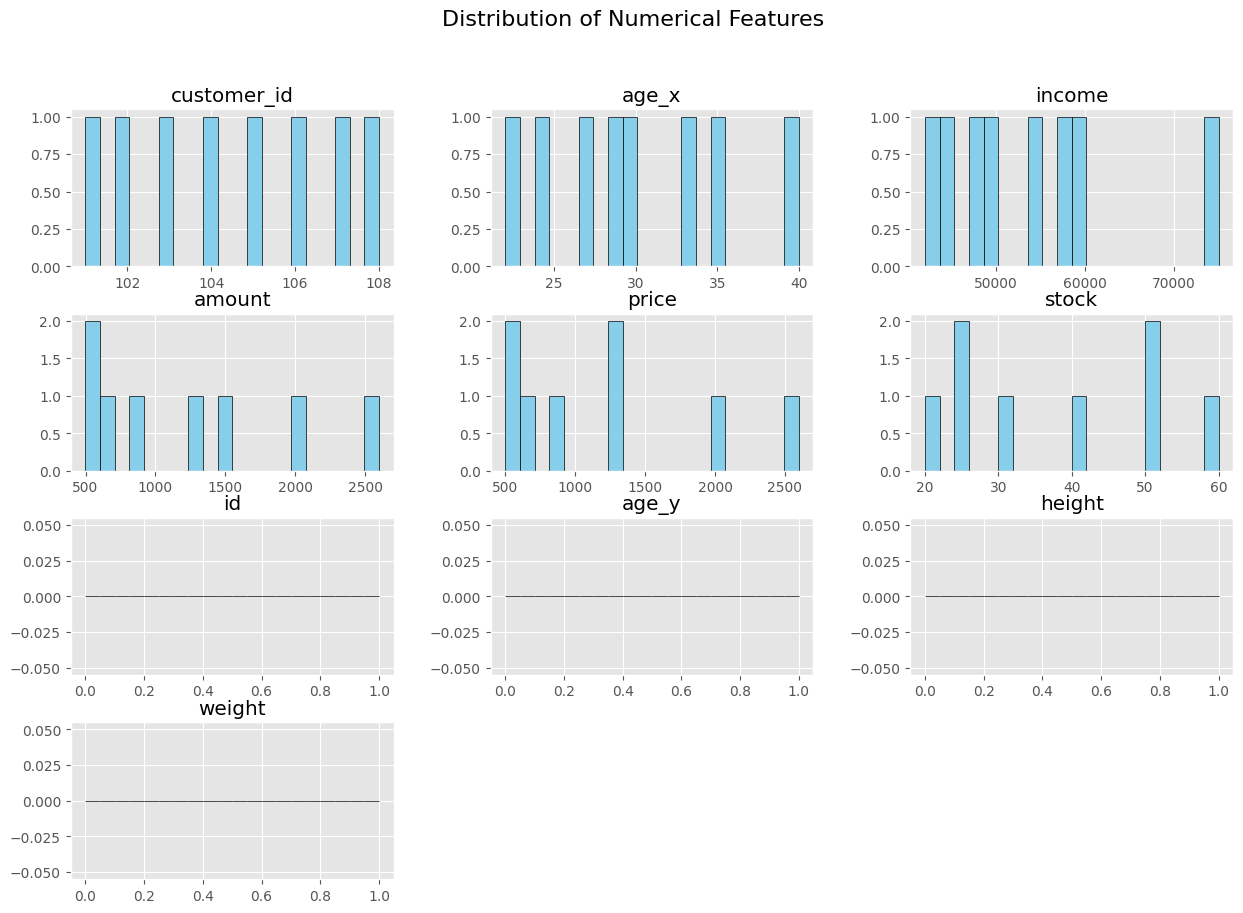

In [ ]:
import matplotlib.pyplot as plt

numerical_columns = final_data.select_dtypes(include=["int64","float64"]).columns

final_data[numerical_columns].hist(
    figsize=(15,10),
    bins=20,
    color="skyblue",
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.show()

This code extracts all categorical columns from the dataset. Categorical variables contain text-based information such as customer names, gender, city, payment mode, or product category. Identifying these columns helps apply appropriate preprocessing techniques like encoding or frequency analysis.

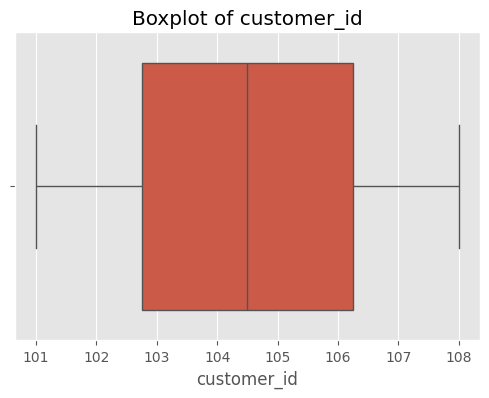

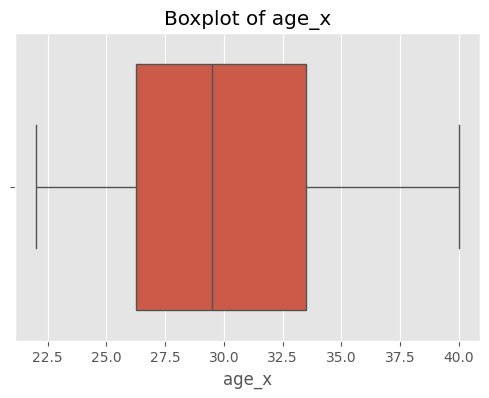

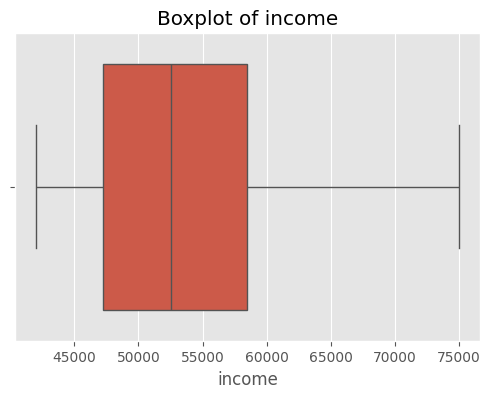

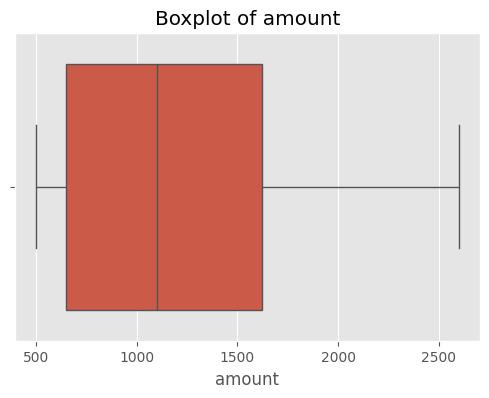

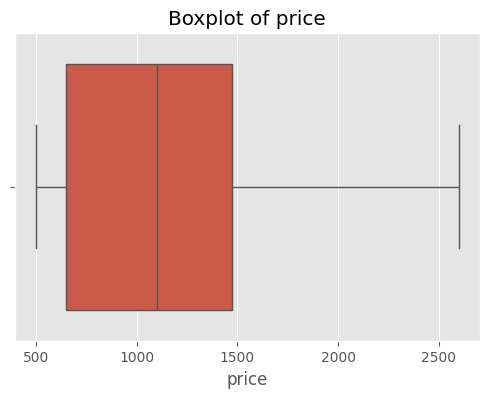

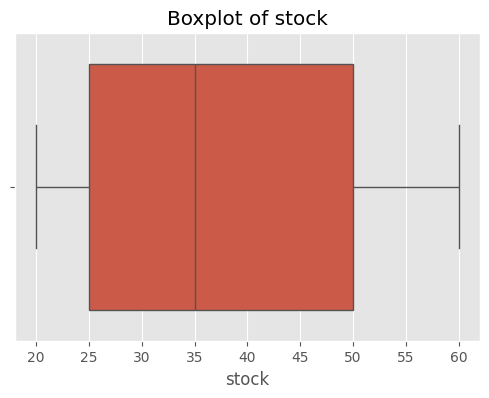

Skipping boxplot for 'id' as it contains only NaN values.
Skipping boxplot for 'age_y' as it contains only NaN values.
Skipping boxplot for 'height' as it contains only NaN values.
Skipping boxplot for 'weight' as it contains only NaN values.


In [ ]:
for column in numerical_columns:
    # Only plot if the column has at least one non-null value
    if final_data[column].notna().any():
        plt.figure(figsize=(6,4))

        sns.boxplot(
            x=final_data[column]
        )

        plt.title(f"Boxplot of {column}")

        plt.show()
    else:
        print(f"Skipping boxplot for '{column}' as it contains only NaN values.")

This code creates histograms for every numerical column that contains valid values. Histograms show how data is distributed, whether it is normally distributed, skewed, or contains unusual patterns. These plots help determine if data transformation or normalization may be required.

In [ ]:
print(final_data[numerical_columns].skew())

customer_id    0.000000
age_x          0.366520
income         1.073956
amount         0.813569
price          0.960237
stock          0.341565
id                  NaN
age_y               NaN
height              NaN
weight              NaN
dtype: float64


This code calculates the skewness of every numerical feature. Skewness indicates whether the data is symmetric or biased toward one side. Positive skew means values are concentrated on the left with a long right tail, while negative skew indicates the opposite.

In [ ]:
print(final_data.columns)

Index(['customer_id', 'name', 'age_x', 'gender_x', 'city', 'income',
       'transaction_id', 'product_id', 'amount', 'payment_mode', 'date',
       'product_name', 'category', 'price', 'stock', 'id', 'firstName',
       'lastName', 'maidenName', 'age_y', 'gender_y', 'email', 'phone',
       'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height',
       'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress',
       'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto',
       'role'],
      dtype='object')



This code prints the names of every column in the final dataset. Reviewing column names helps verify that all expected features are present after merging and preprocessing.

In [ ]:
correlation = final_data.corr(numeric_only=True)

print(correlation["amount"].sort_values(ascending=False))

amount         1.000000
price          0.995623
income         0.629398
age_x          0.624180
customer_id    0.408904
stock         -0.787507
id                  NaN
age_y               NaN
height              NaN
weight              NaN
Name: amount, dtype: float64


This code computes the correlation matrix for all numerical variables and displays how strongly each feature is related to the amount column. Features with higher positive or negative correlation may have a stronger influence on transaction amount.

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


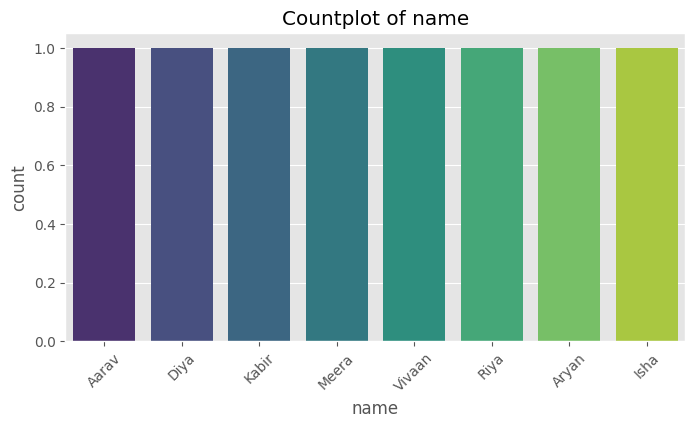

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


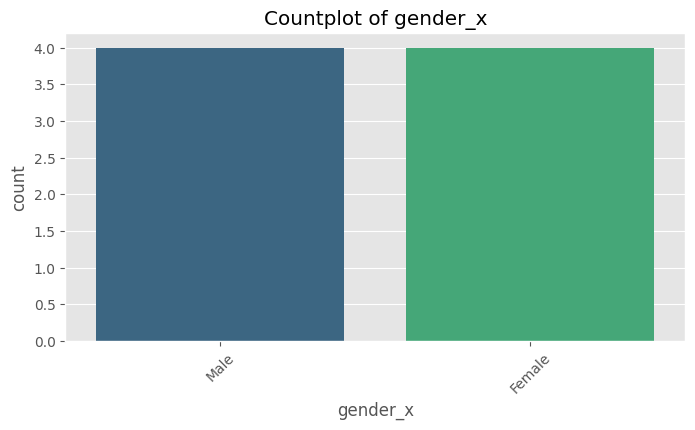

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


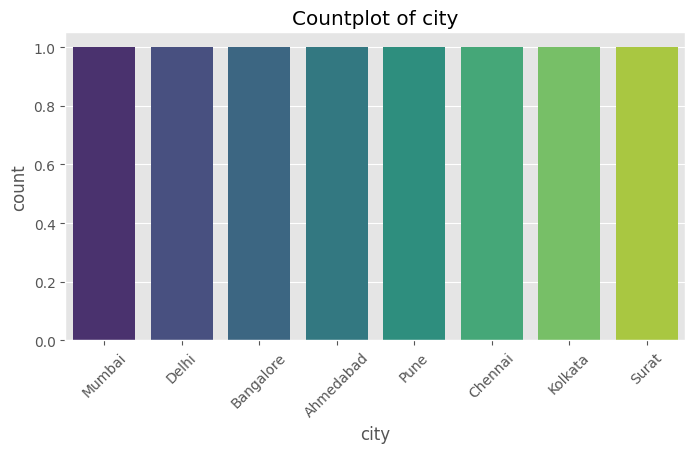

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


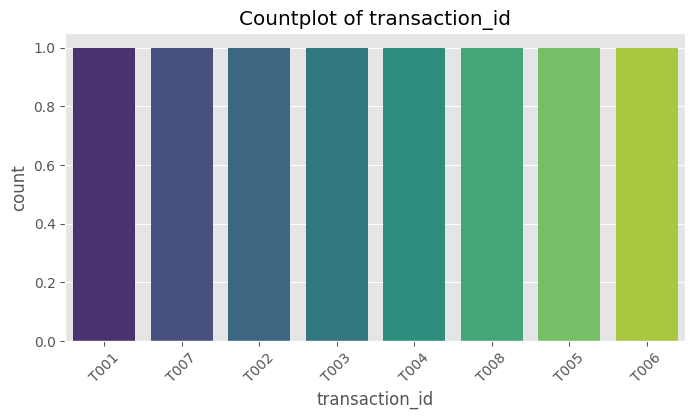

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


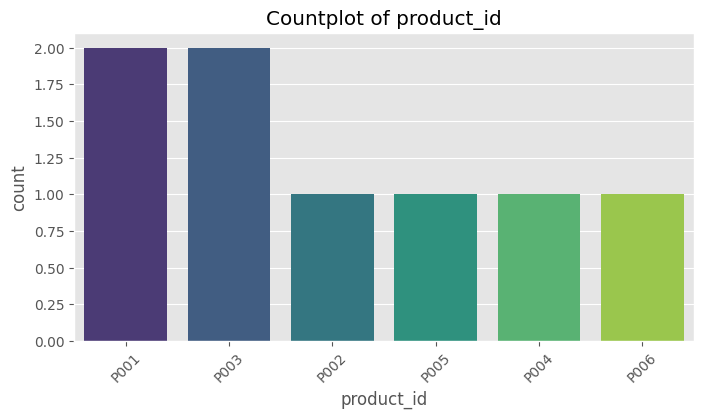

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


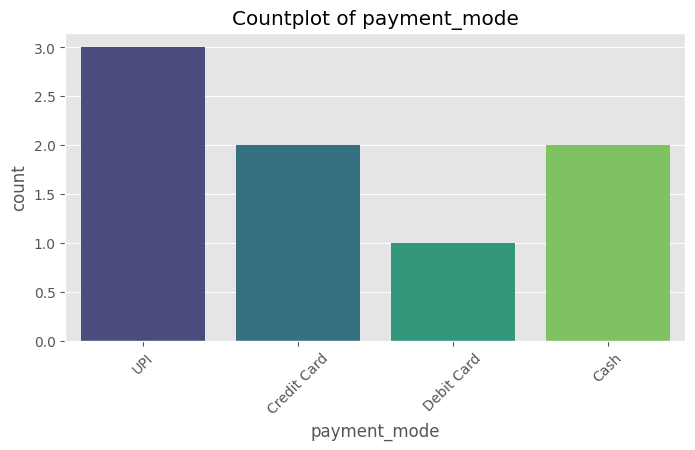

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


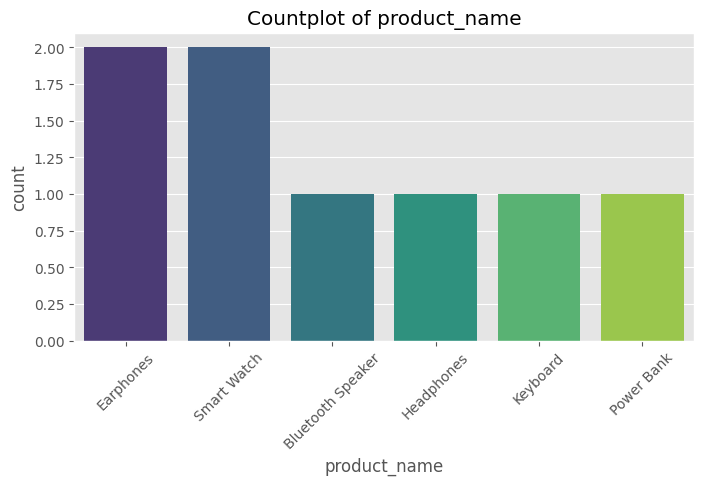

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


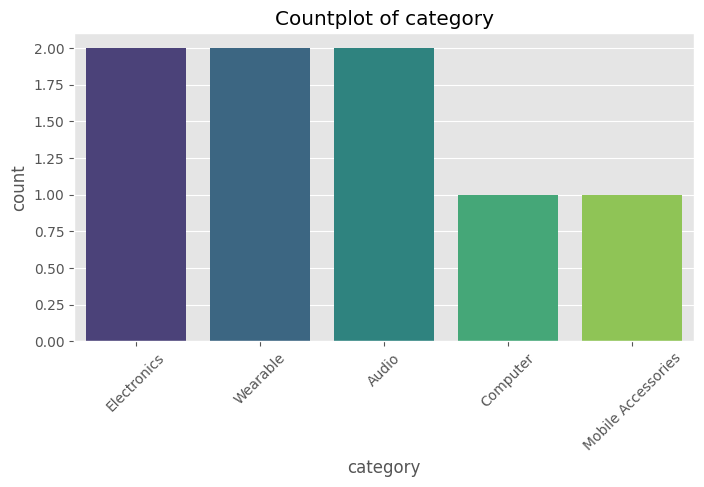

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


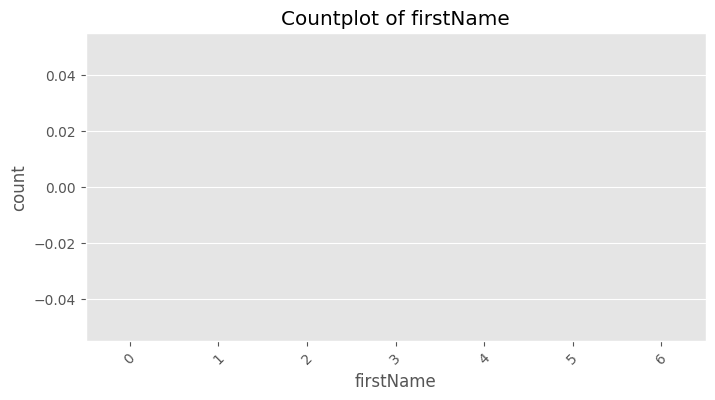

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


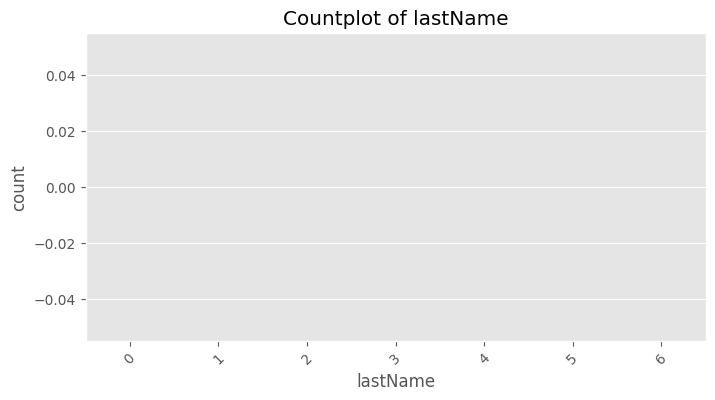

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


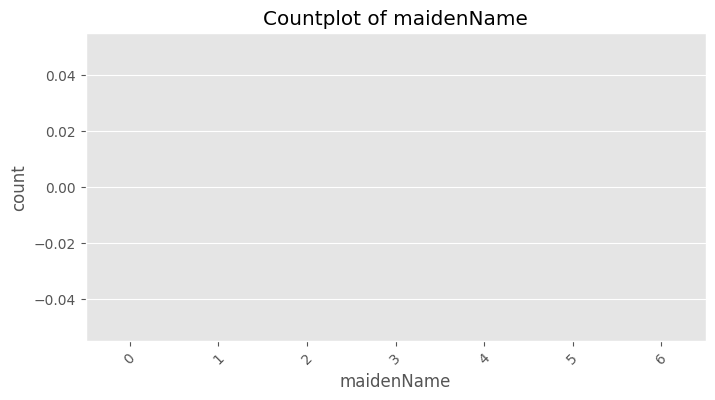

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


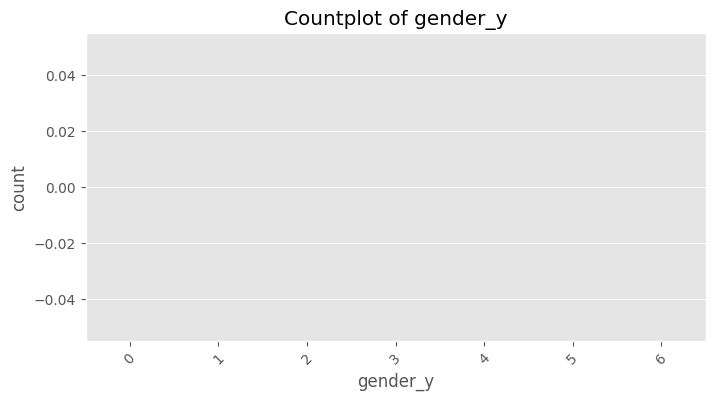

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


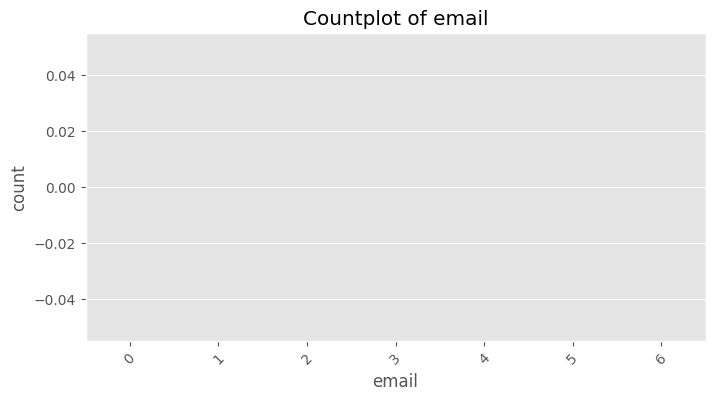

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


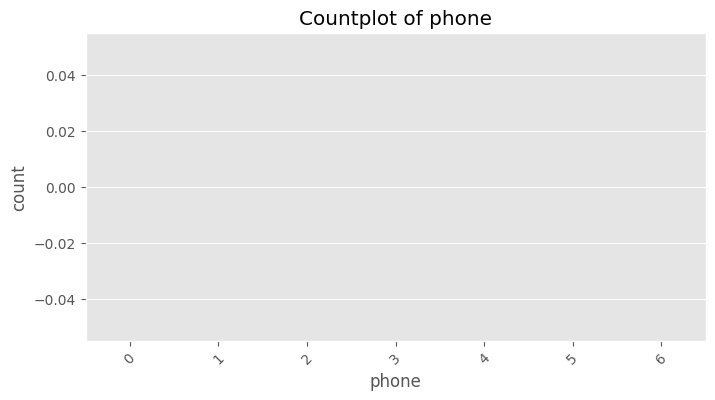

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


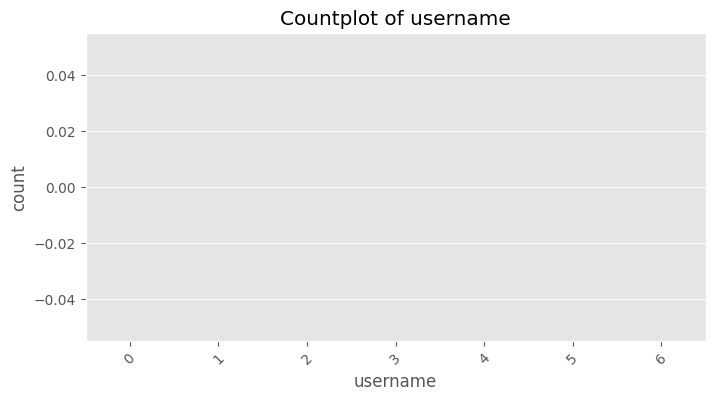

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


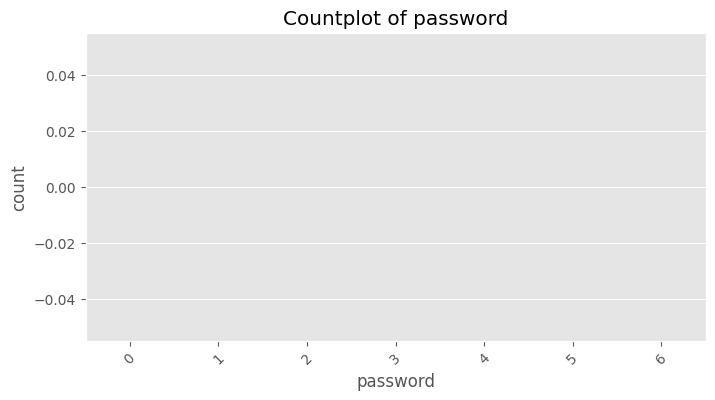

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


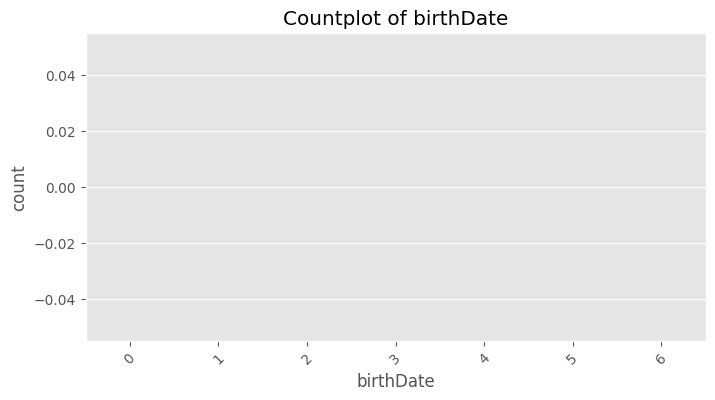

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


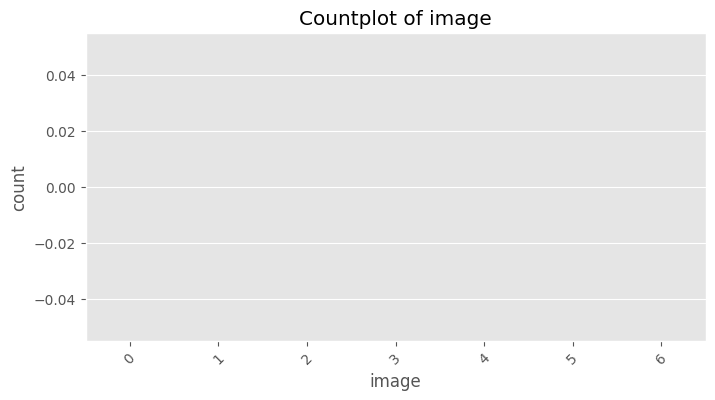

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


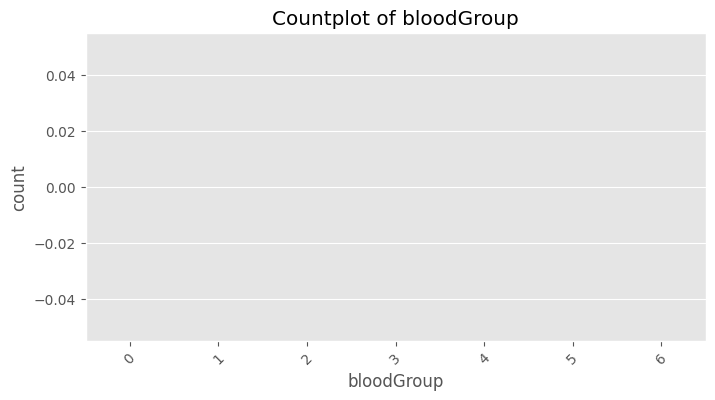

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


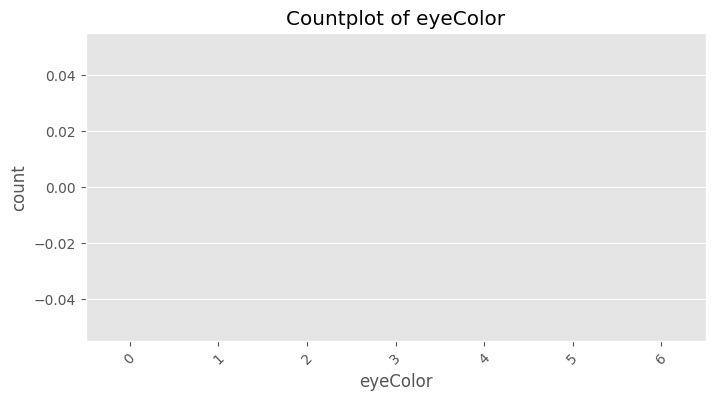

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


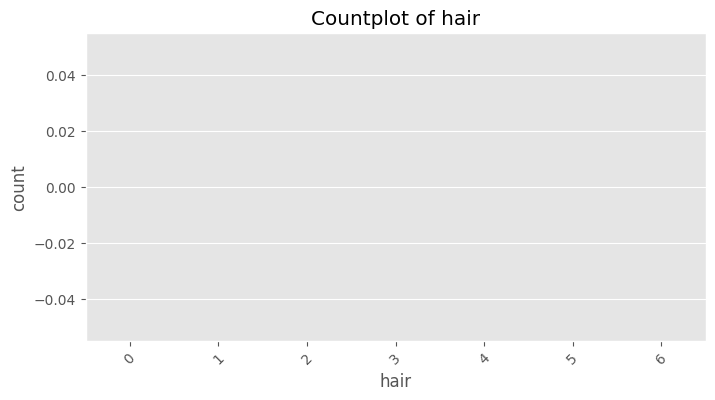

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


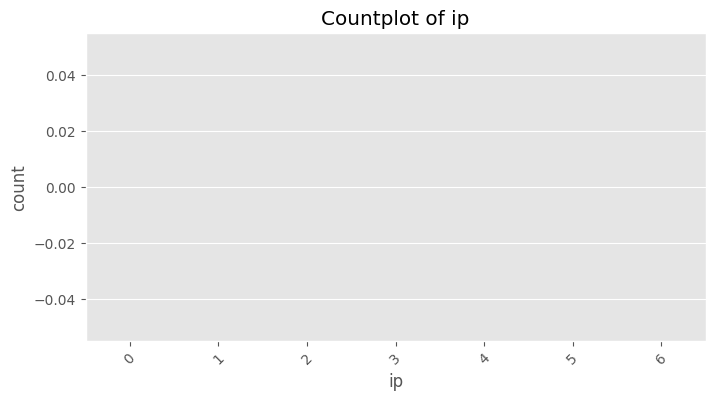

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


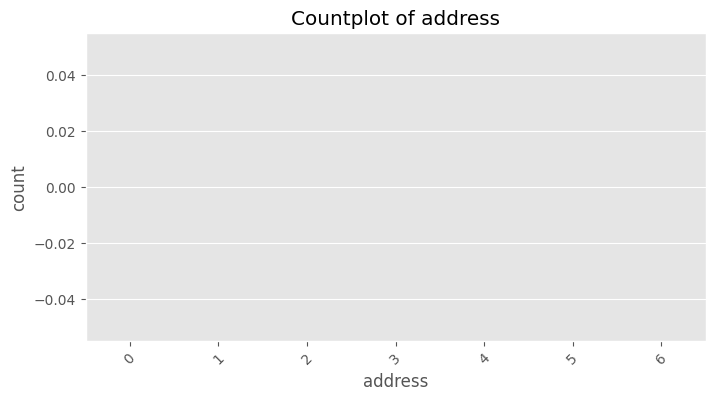

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


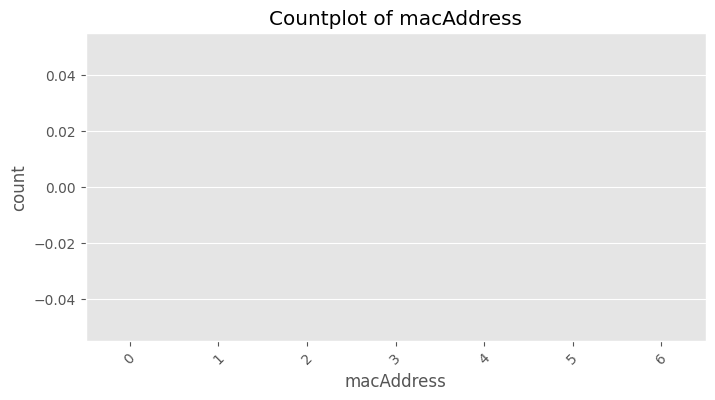

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


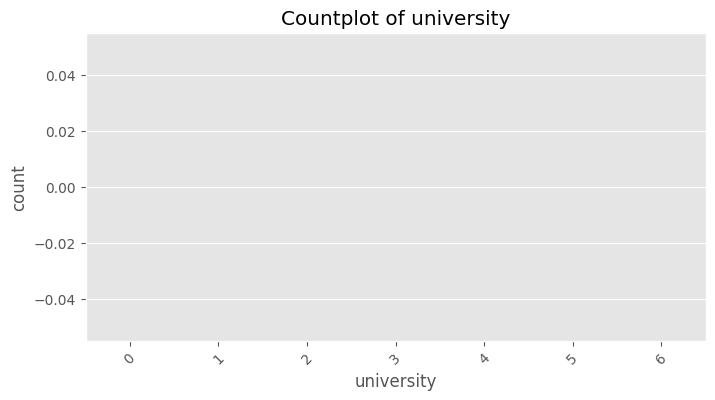

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


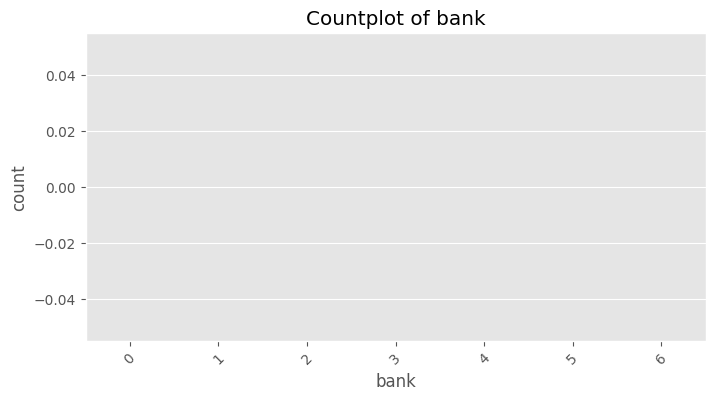

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


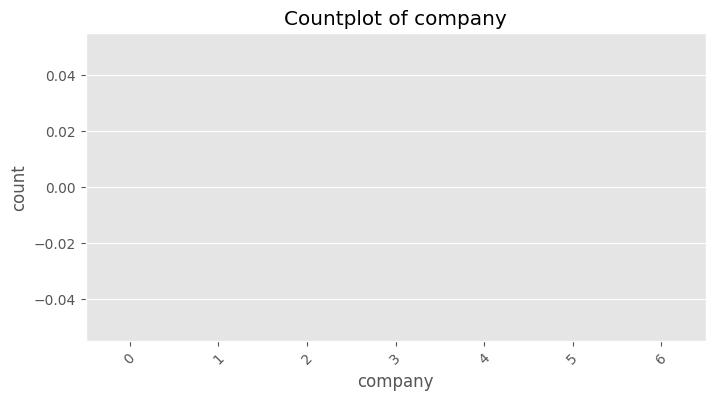

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


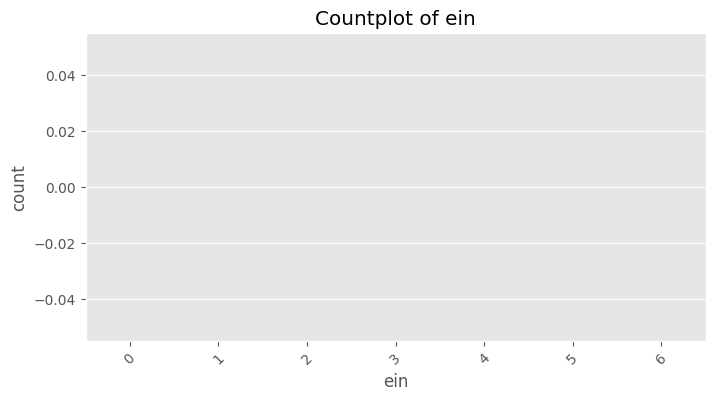

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


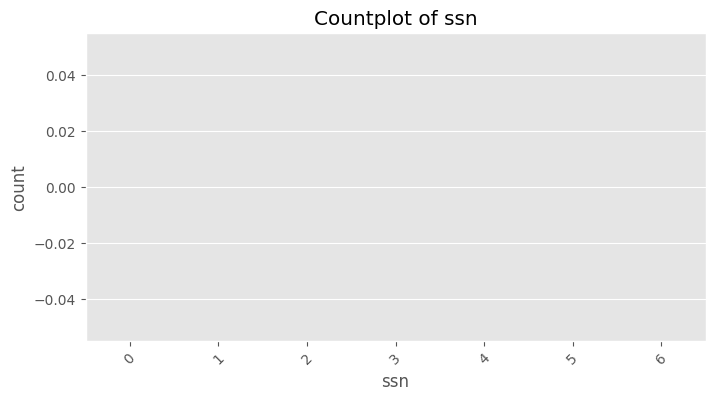

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


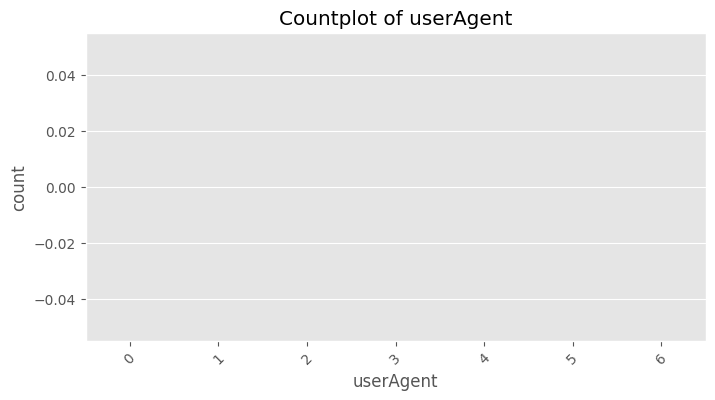

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


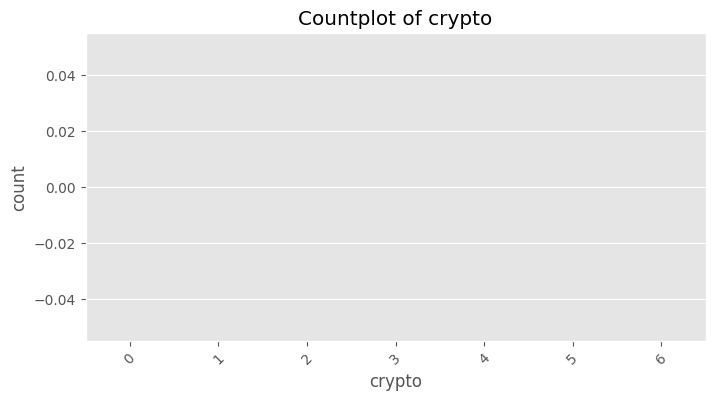

/tmp/ipykernel_2667/450636856.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_2667/450636856.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.countplot(


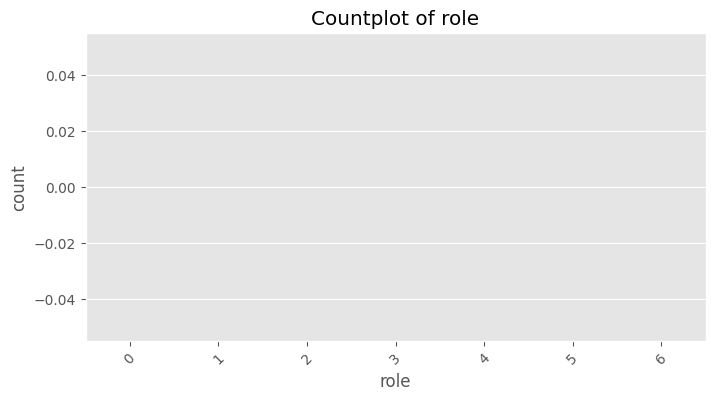

In [ ]:
categorical_columns = final_data.select_dtypes(include=["object"]).columns

for col in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=final_data,
        x=col,
        palette="viridis"
    )

    plt.xticks(rotation=45)

    plt.title(f"Countplot of {col}")

    plt.show()

This code loops through every categorical column and examines its values. This helps understand the categories present in each feature and identify inconsistencies such as spelling mistakes, unnecessary spaces, or duplicate category names.

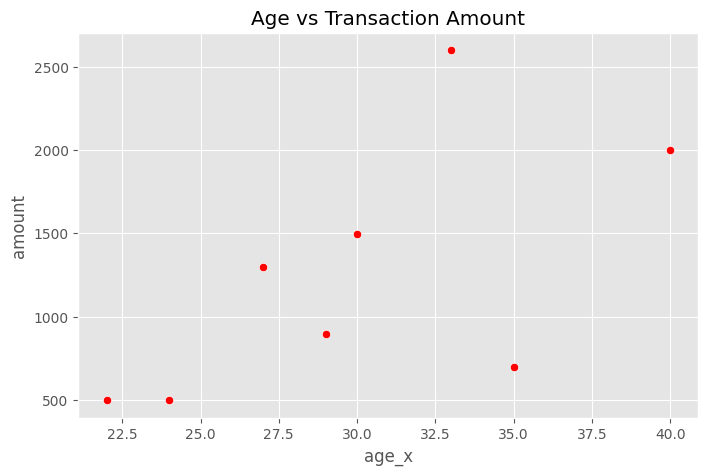

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=final_data,
    x="age_x",
    y="amount",
    color="red"
)

plt.title("Age vs Transaction Amount")

plt.show()

This code creates a scatter plot to visualize the relationship between two numerical variables. Scatter plots help identify trends, clusters, and potential outliers. They also show whether two variables have a positive, negative, or weak relationship.

/tmp/ipykernel_2667/11374432.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


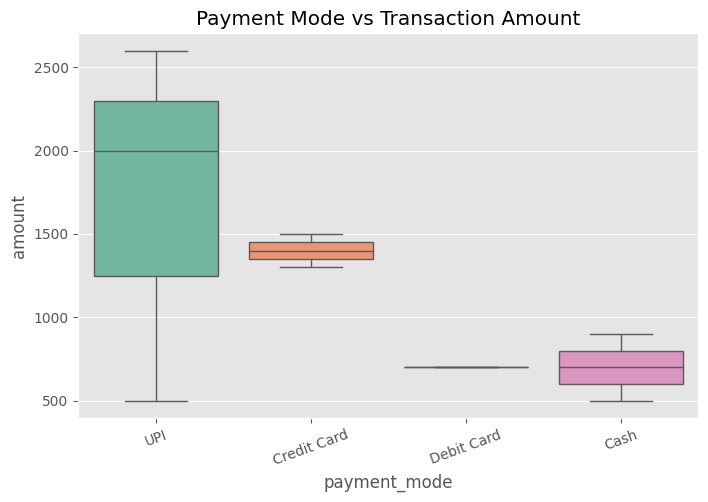

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=final_data,
    x="payment_mode",
    y="amount",
    palette="Set2"
)

plt.xticks(rotation=20)

plt.title("Payment Mode vs Transaction Amount")

plt.show()

This code generates a box plot for a selected feature. The box plot summarizes the distribution using the median, quartiles, and whiskers while highlighting outliers. It is an effective tool for detecting extreme observations that could affect model performance.

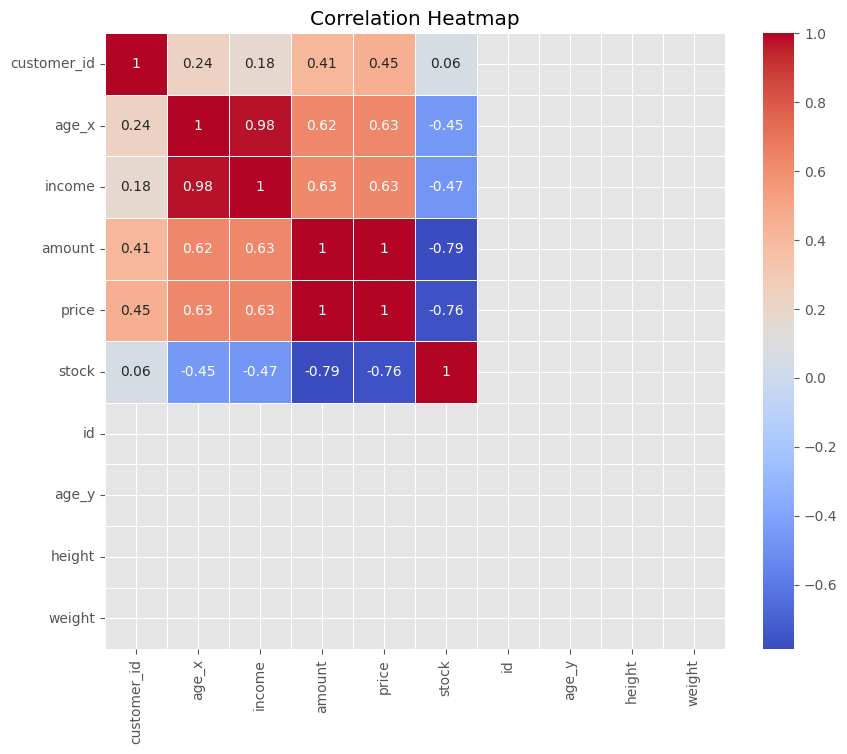

In [ ]:
plt.figure(figsize=(10,8))

corr = final_data[numerical_columns].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()

This code calculates the correlation matrix of all numerical features and visualizes it using a heatmap. The heatmap makes it easier to identify highly correlated variables, which can be useful during feature selection and multicollinearity analysis.

In [ ]:
final_data.groupby("payment_mode")["amount"].mean()

,amount
payment_mode,
Cash,699.0
Credit Card,1399.0
Debit Card,699.0
UPI,1699.0


This code  groups the dataset by payment mode and calculates the average transaction amount for each category. Comparing these averages helps identify which payment methods are associated with higher or lower spending.

/tmp/ipykernel_2667/848150702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


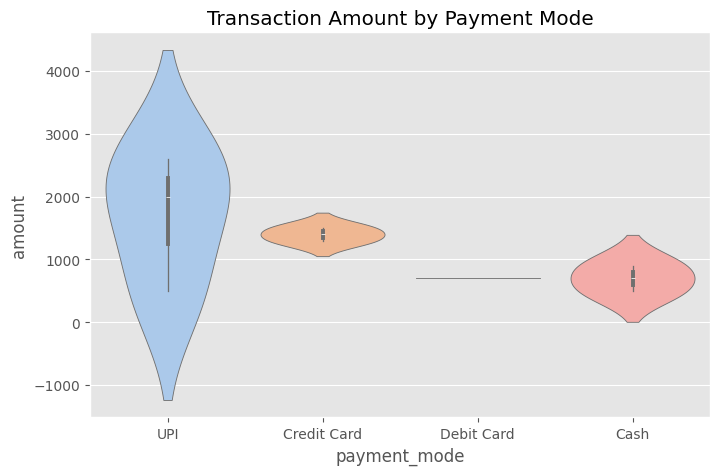

In [ ]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=final_data,
    x="payment_mode",
    y="amount",
    palette="pastel"
)

plt.title("Transaction Amount by Payment Mode")

plt.show()

This code creates a violin plot to show the distribution of a numerical variable across categories. Unlike a box plot, the violin plot also displays the density of the data, making it easier to understand where observations are concentrated.

Why this cell is used:
To compare data distributions across different groups.

Outcome:
A violin plot is displayed.

In [ ]:
# Check missing values

final_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code used to check the sum of null in each coloumn .


In [ ]:
numerical_cols = final_data.select_dtypes(include=["int64","float64"]).columns

categorical_cols = final_data.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['customer_id', 'age_x', 'income', 'amount', 'price', 'stock', 'id',
       'age_y', 'height', 'weight'],
      dtype='object')

Categorical Columns:
Index(['name', 'gender_x', 'city', 'transaction_id', 'product_id',
       'payment_mode', 'product_name', 'category', 'firstName', 'lastName',
       'maidenName', 'gender_y', 'email', 'phone', 'username', 'password',
       'birthDate', 'image', 'bloodGroup', 'eyeColor', 'hair', 'ip', 'address',
       'macAddress', 'university', 'bank', 'company', 'ein', 'ssn',
       'userAgent', 'crypto', 'role'],
      dtype='object')


This code creates separate lists of numerical and categorical columns before applying missing value treatments. Different data types require different imputation strategies, so separating them improves preprocessing accuracy.

In [ ]:
from sklearn.impute import SimpleImputer

simple_mean = final_data.copy()

mean_imputer = SimpleImputer(strategy="mean")

# Identify numerical columns that are not entirely NaN
imputable_numerical_cols = numerical_cols[simple_mean[numerical_cols].notna().any()]

simple_mean[imputable_numerical_cols] = mean_imputer.fit_transform(
    simple_mean[imputable_numerical_cols]
)

simple_mean.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code creates a copy of the dataset and uses the SimpleImputer with the mean strategy to replace missing numerical values. Mean imputation is commonly used when numerical data is approximately normally distributed.

Why this cell is used:
To fill missing numerical values using the average of each feature.

Outcome:
A new dataset with mean-imputed values is created.

In [ ]:
simple_median = final_data.copy()

median_imputer = SimpleImputer(strategy="median")

# Identify numerical columns that are not entirely NaN
imputable_numerical_cols = numerical_cols[simple_median[numerical_cols].notna().any()]

simple_median[imputable_numerical_cols] = median_imputer.fit_transform(
    simple_median[imputable_numerical_cols]
)

simple_median.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code replaces missing numerical values using the median instead of the mean. Median imputation is more robust because it is less affected by extreme values and outliers.

Why this cell is used:
To handle missing values in skewed numerical features.

Outcome:
A dataset with median-imputed values is created.

Cell 38 – Mode Imputation

In [ ]:
mode_data = final_data.copy()

mode_imputer = SimpleImputer(strategy="most_frequent")

# Identify categorical columns that are not entirely NaN
imputable_categorical_cols = categorical_cols[mode_data[categorical_cols].notna().any()]

mode_data[imputable_categorical_cols] = mode_imputer.fit_transform(
    mode_data[imputable_categorical_cols]
)

mode_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code fills missing values using the most frequently occurring value in each column. Mode imputation is especially useful for categorical variables where the most common category can replace missing entries.

Why this cell is used:
To handle missing values in categorical data.

Outcome:
A dataset with mode-imputed values is generated.

In [ ]:
constant_data = final_data.copy()

constant_imputer = SimpleImputer(
    strategy="constant",
    fill_value="Unknown"
)

constant_data[categorical_cols] = constant_imputer.fit_transform(
    constant_data[categorical_cols]
)

constant_data.isnull().sum()

/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:572: FutureWarning: Currently, when `keep_empty_feature=False` and `strategy="constant"`, empty features are not dropped. This behaviour will change in version 1.8. Set `keep_empty_feature=True` to preserve this behaviour.
  warnings.warn(


,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This code replaces missing values with a constant value specified in the imputer. Using a constant placeholder preserves missing information while ensuring the dataset contains no null values.

In [ ]:
from sklearn.impute import MissingIndicator

indicator = MissingIndicator(features="missing-only")

indicator_values = indicator.fit_transform(final_data)

indicator_columns = indicator.features_

print(indicator_columns)

[15 16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38
 39 40 41 42]


This code uses MissingIndicator from Scikit-learn to create new binary features indicating whether a value was originally missing. These indicators allow machine learning models to learn patterns related to missing information, which can sometimes improve predictive performance.

In [ ]:
import numpy as np

random_sample = final_data.copy()

for col in numerical_cols:
    # Only attempt random sampling if the column has at least one non-null value to sample from
    if random_sample[col].notna().any():
        # Check if the column also has missing values to impute
        if random_sample[col].isnull().sum() > 0:

            random_values = random_sample[col].dropna().sample(
                random_sample[col].isnull().sum(),
                replace=True,
                random_state=42
            )

            random_values.index = random_sample[
                random_sample[col].isnull()
            ].index

            random_sample.loc[
                random_sample[col].isnull(),
                col
            ] = random_values


This code creates a copy of the dataset and fills missing numerical values using random sampling. Instead of replacing missing values with the mean or median, it randomly selects existing values from the same column. This method helps preserve the original distribution of the data and introduces less bias than simple statistical imputation.

This cell checks whether any missing values remain after applying random sample imputation. It counts the null values in every column to confirm that the imputation process was successful.

Why this cell is used:
To verify that random imputation removed missing values correctly.

Outcome:
The number of missing values remaining in each column is displayed.

In [ ]:
random_sample.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


Check the null values for each columns.

In [ ]:
from sklearn.impute import KNNImputer

knn_data = final_data.copy()

knn = KNNImputer(n_neighbors=5)

# Filter numerical columns to exclude those that are entirely NaN
imputable_numerical_cols = numerical_cols[knn_data[numerical_cols].notna().any()]

# Apply KNNImputer only to the imputable numerical columns
knn_data[imputable_numerical_cols] = knn.fit_transform(
    knn_data[imputable_numerical_cols]
)

knn_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This cell applies the K-Nearest Neighbors (KNN) Imputer to estimate missing numerical values. The algorithm finds records with similar characteristics and uses their values to replace missing entries. Compared to mean or median imputation, KNN often produces more realistic estimates because it considers relationships among features.


In [ ]:
from sklearn.impute import KNNImputer

knn_data = final_data.copy()

knn = KNNImputer(n_neighbors=5)

# Filter numerical columns to exclude those that are entirely NaN
imputable_numerical_cols = numerical_cols[knn_data[numerical_cols].notna().any()]

# Apply KNNImputer only to the imputable numerical columns
knn_data[imputable_numerical_cols] = knn.fit_transform(
    knn_data[imputable_numerical_cols]
)

knn_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This cell displays the dataset after KNN imputation or checks the remaining missing values. It ensures that the imputation process was successful and allows comparison with previous imputation methods.

Why this cell is used:
To validate the results of KNN imputation.

Outcome:
The updated dataset or missing value summary is displayed.

In [ ]:
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import IterativeImputer

mice_data = final_data.copy()

mice = IterativeImputer(random_state=42)

# Filter numerical columns to exclude those that are entirely NaN
imputable_numerical_cols = numerical_cols[mice_data[numerical_cols].notna().any()]

# Apply IterativeImputer only to the imputable numerical columns
mice_data[imputable_numerical_cols] = mice.fit_transform(
    mice_data[imputable_numerical_cols]
)

mice_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This cell uses the Iterative Imputer, also known as Multiple Imputation by Chained Equations (MICE). It predicts missing values using regression models based on other variables in the dataset. This is one of the most sophisticated imputation techniques because it captures relationships among multiple features.

Why this cell is used:
To improve missing value estimation using predictive modeling.

Outcome:
A dataset with iteratively imputed values is created.

Cell 46 – Fetch Additional Data from A

In [ ]:
import requests
import pandas as pd

url = "https://dummyjson.com/users"

response = requests.get(url)

api_df = pd.DataFrame(response.json()["users"])

api_df.head()

,id,firstName,lastName,maidenName,age,gender,email,phone,username,password,...,address,macAddress,university,bank,company,ein,ssn,userAgent,crypto,role
0,1,Emily,Johnson,Smith,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,emilyspass,...,"{'address': '626 Main Street', 'city': 'Phoeni...",47:fa:41:18:ec:eb,University of Wisconsin--Madison,"{'cardExpire': '05/28', 'cardNumber': '3693233...","{'department': 'Engineering', 'name': 'Dooley,...",977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
1,2,Michael,Williams,,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,michaelwpass,...,"{'address': '385 Fifth Street', 'city': 'Houst...",79:15:78:99:60:aa,Ohio State University,"{'cardExpire': '01/30', 'cardNumber': '3530633...","{'department': 'Support', 'name': 'Spinka - Di...",912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
2,3,Sophia,Brown,,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,sophiabpass,...,"{'address': '1642 Ninth Street', 'city': 'Wash...",12:a3:d3:6f:5c:5b,Pepperdine University,"{'cardExpire': '10/27', 'cardNumber': '6011212...","{'department': 'Research and Development', 'na...",963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
3,4,James,Davis,,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,jamesdpass,...,"{'address': '238 Jefferson Street', 'city': 'S...",10:7d:df:1f:97:58,University of Southern California,"{'cardExpire': '07/30', 'cardNumber': '5303440...","{'department': 'Support', 'name': 'Pagac and S...",904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin
4,5,Emma,Miller,Johnson,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,emmajpass,...,"{'address': '607 Fourth Street', 'city': 'Jack...",32:b9:7e:8d:f5:e8,Northeastern University,"{'cardExpire': '07/30', 'cardNumber': '5237188...","{'department': 'Human Resources', 'name': 'Gra...",403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin


This cell retrieves user information from an online API using the requests library. The JSON response is converted into a Pandas DataFrame so it can later be merged with the existing dataset.

Why this cell is used:
To demonstrate data collection from external web services.

Outcome:
Customer information from the API is loaded into a DataFrame.

In [ ]:
api_df = api_df.iloc[:8].copy()

api_df["id"] = [101,102,103,104,105,106,107,108]

This code selects only the required records from the API data and assigns custom customer IDs so they match the IDs in the main dataset. This preparation ensures that the merge operation will work correctly.

Why this code is used:
To align API data with the existing customer datas

In [ ]:
final_data = pd.merge(
    merged_data,
    api_df,
    left_on="customer_id",
    right_on="id",
    how="left"
)

final_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This cell merges the processed API information with the existing dataset using customer IDs. The resulting dataset now contains both original customer information and additional attributes obtained from the API.

Why this cell is used:
To enrich the dataset with external information.

Outcome:
The final merged dataset contains additional customer details.

In [ ]:
import numpy as np
import pandas as pd

from scipy.stats import zscore
from scipy.stats.mstats import winsorize

This code imports libraries such as NumPy, Pandas, and SciPy's zscore function, which are required for detecting outliers. Outlier detection is an important preprocessing step because extreme values can negatively affect machine learning models.

Why this cell is used:
To prepare the environment for outlier analysis.

Outcome:
Required libraries for outlier detection are successfully imported.

In [ ]:
numerical_cols = final_data.select_dtypes(include=["int64","float64"]).columns

print(numerical_cols)

Index(['customer_id', 'age_x', 'income', 'amount', 'price', 'stock', 'id',
       'age_y', 'height', 'weight'],
      dtype='object')


This code used to show numerical columns,

In [ ]:
z_scores = np.abs(zscore(final_data[numerical_cols]))

z_scores = pd.DataFrame(
    z_scores,
    columns=numerical_cols
)

z_scores.head()

,customer_id,age_x,income,amount,price,stock,id,age_y,height,weight
0,1.527525,1.086429,0.929578,1.060660,1.033738,0.912871,1.527525,0.721594,0.931783,0.075691
1,1.091089,0.000000,0.089138,0.353553,0.106938,0.912871,1.091089,0.218156,0.395955,1.511718
2,0.654654,0.543214,0.623963,0.070711,0.106938,0.912871,0.654654,1.157907,0.252839,1.349479
3,0.218218,0.905357,0.598495,0.777817,0.748569,0.182574,0.218218,1.560658,0.937126,0.203553
4,0.218218,1.810715,2.126569,1.060660,1.105031,0.547723,0.218218,0.453094,0.898198,0.020204


This cell identifies all numerical variables that will be examined for outliers. Since outlier detection techniques such as Z-score and IQR work only on numerical data, selecting these columns is necessary.

Why this cell is used:
To isolate numerical features before detecting outliers.

Outcome:
A list of numerical columns is prepared.

In [ ]:
threshold = 3

zscore_data = final_data[
    (z_scores < threshold).all(axis=1)
]

print("Original Shape :", final_data.shape)

print("After Z-Score :", zscore_data.shape)

Original Shape : (8, 43)
After Z-Score : (8, 43)


This cell computes the absolute Z-score for every numerical feature. A Z-score measures how far a value lies from the mean in terms of standard deviations. Large Z-score values indicate potential outliers.

Why this cell is used:
To identify unusually large or small observations.

Outcome:
A DataFrame containing Z-score values for all numerical features is generated.

In [ ]:
iqr_data = final_data.copy()

for col in numerical_cols:

    Q1 = iqr_data[col].quantile(0.25)

    Q3 = iqr_data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR

    upper = Q3 + 1.5 * IQR

    iqr_data = iqr_data[
        (iqr_data[col] >= lower) &
        (iqr_data[col] <= upper)
    ]

print("Original Shape :", final_data.shape)

print("After IQR :", iqr_data.shape)

Original Shape : (8, 43)
After IQR : (8, 43)


This cell detects outliers using the Interquartile Range (IQR) method. Values falling below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are removed. This approach is particularly effective for skewed datasets.

Why this cell is used:
To identify outliers without assuming a normal distribution.



In [ ]:
percentile_data = final_data.copy()

for col in numerical_cols:

    lower = percentile_data[col].quantile(0.01)

    upper = percentile_data[col].quantile(0.99)

    percentile_data = percentile_data[
        (percentile_data[col] >= lower) &
        (percentile_data[col] <= upper)
    ]

print("Original Shape :", final_data.shape)

print("After Percentile :", percentile_data.shape)

Original Shape : (8, 43)
After Percentile : (0, 43)


This cell removes extremely low and high values using percentile thresholds. Observations outside the selected percentile range are excluded, reducing the influence of extreme values while preserving most of the data.

Why this cell is used:
To remove outliers using percentile boundaries.

Outcome:
A dataset named percentile_data is created.

In [ ]:
winsor_data = final_data.copy()

for col in numerical_cols:

    winsor_data[col] = winsorize(
        winsor_data[col],
        limits=[0.05,0.05]winsor_data[numerical_cols].describe()
    )

This cell applies Winsorization to cap extreme values instead of deleting them. Values beyond specified limits are replaced with the nearest acceptable boundary. This preserves the number of observations while reducing the effect of outliers.

Why this cell is used:
To reduce the impact of outliers without removing records.

In [ ]:
winsor_data[numerical_cols].describe()

,customer_id,age_x,income,amount,price,stock,id,age_y,height,weight
count,8.00000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.000000,8.000000
mean,104.50000,30.000000,54125.000000,1249.000000,1224.000000,37.500000,104.50000,34.375000,181.032500,63.787500
std,2.44949,5.903994,10494.045931,755.928946,749.761867,14.638501,2.44949,7.963084,14.005801,8.862634
min,101.00000,22.000000,42000.000000,499.000000,499.000000,20.000000,101.00000,23.000000,153.890000,52.600000
25%,102.75000,26.250000,47250.000000,649.000000,649.000000,25.000000,102.75000,28.750000,175.407500,57.770000
50%,104.50000,29.500000,52500.000000,1099.000000,1099.000000,35.000000,104.50000,33.500000,184.415000,62.630000
75%,106.25000,33.500000,58500.000000,1624.000000,1474.000000,50.000000,106.25000,40.000000,192.910000,66.795000
max,108.00000,40.000000,75000.000000,2599.000000,2599.000000,60.000000,108.00000,46.000000,193.310000,77.420000


This cell displays descriptive statistics for the Winsorized dataset. Comparing these statistics with the original data helps evaluate how effectively Winsorization reduced the influence of extreme values.

Why this cell is used:
To assess the results of Winsorization.

Outcome:
Updated summary statistics are displayed

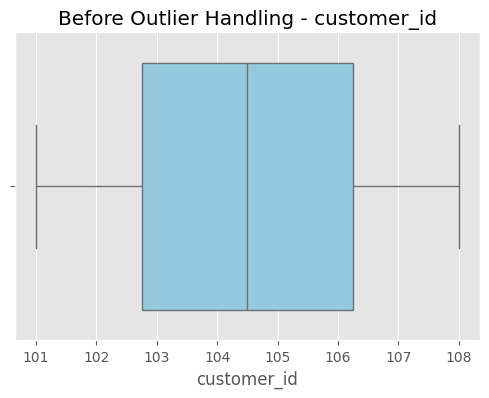

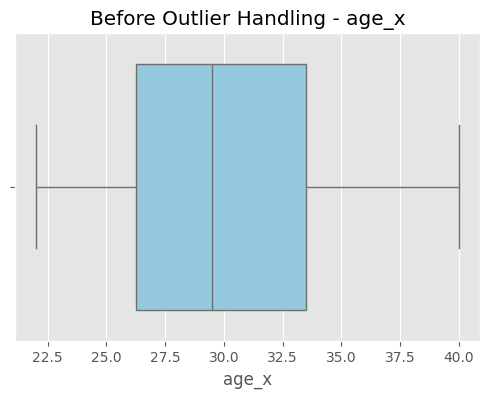

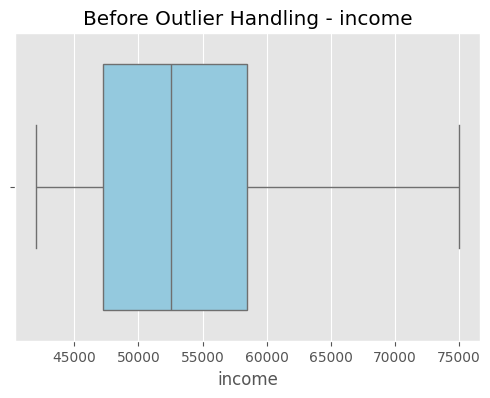

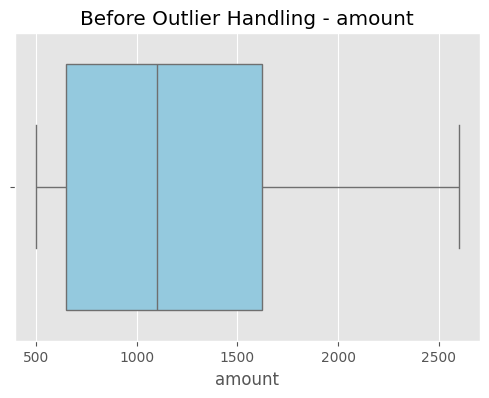

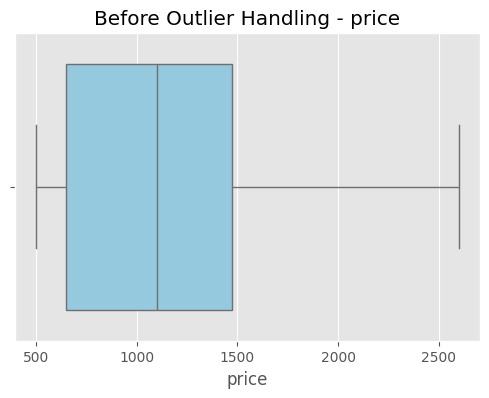

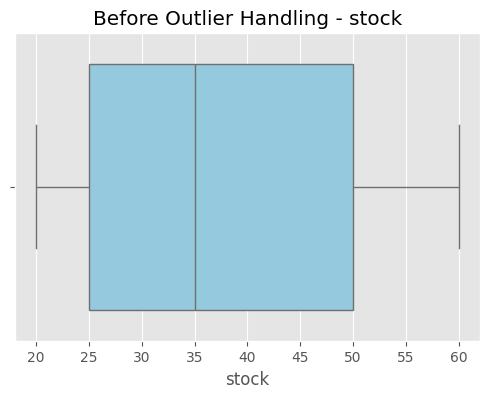

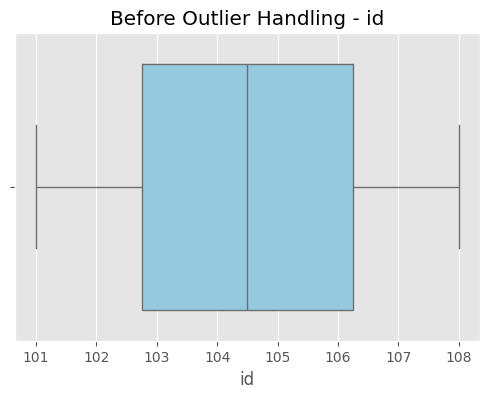

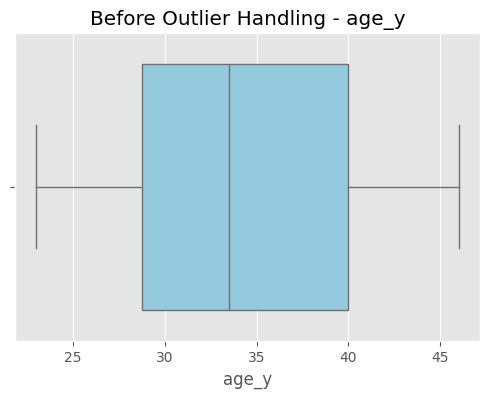

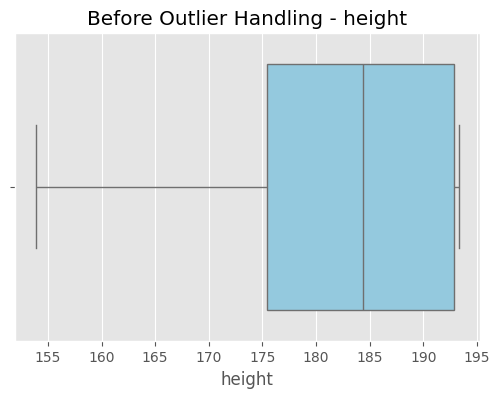

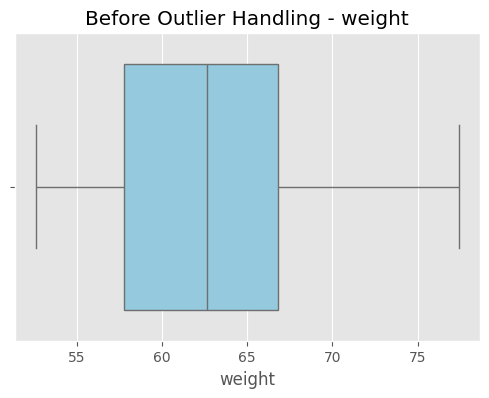

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=final_data[col],
        color="skyblue"
    )

    plt.title(f"Before Outlier Handling - {col}")

    plt.show()

This code used to check uotlier after removing the outlier.

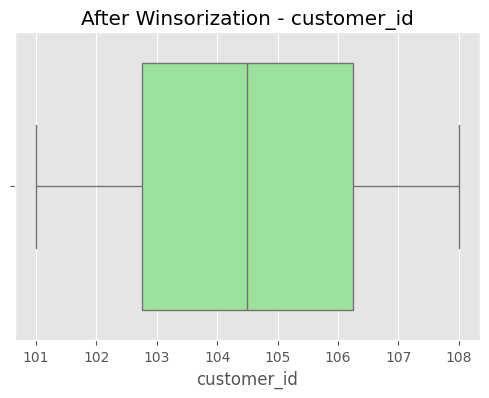

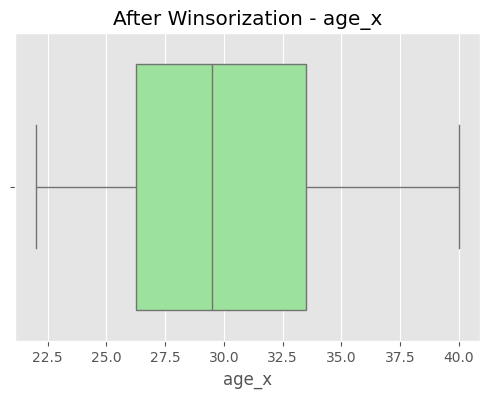

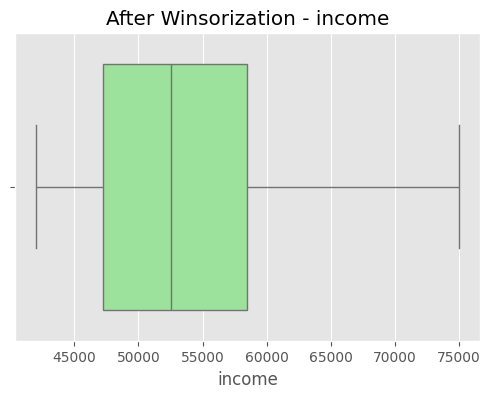

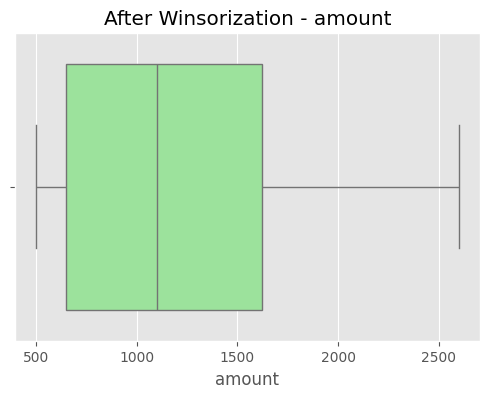

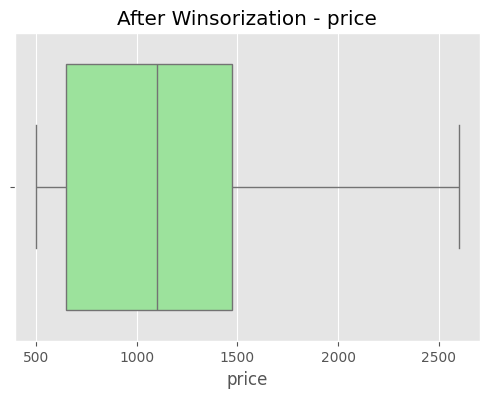

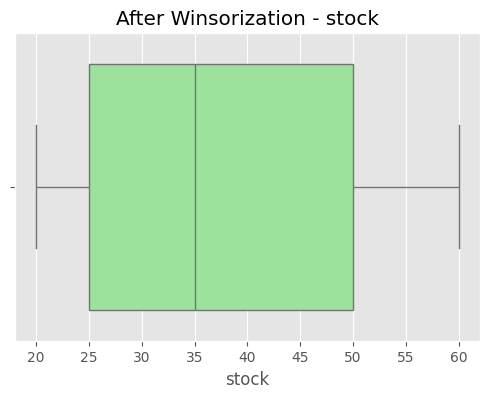

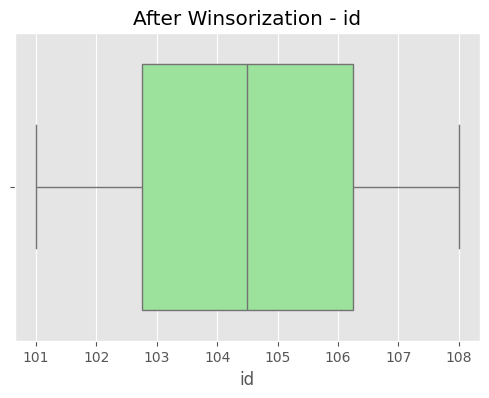

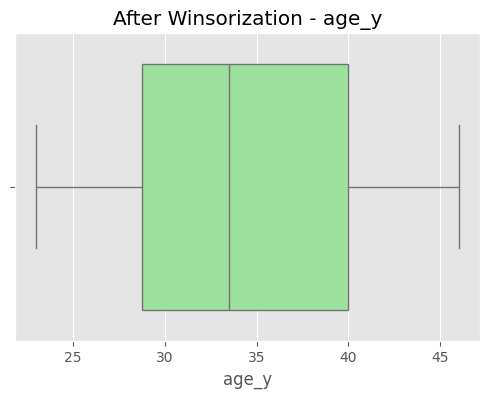

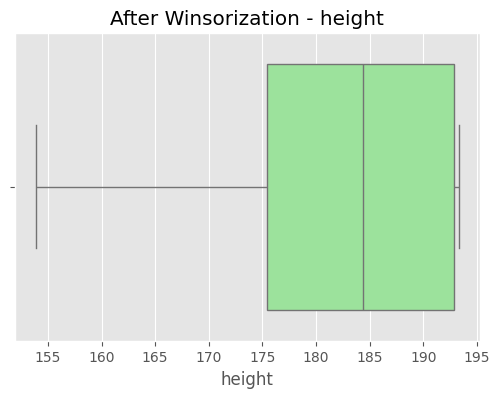

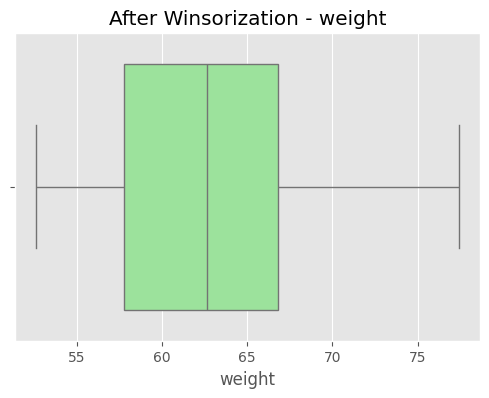

In [ ]:
for col in numerical_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        x=winsor_data[col],
        color="lightgreen"
    )

    plt.title(f"After Winsorization - {col}")

    plt.show()

This code used to Show boxplot after removing the outlier.

In [ ]:
comparison = pd.DataFrame({

    "Method":[
        "Original",
        "Z-Score",
        "IQR",
        "Percentile",
        "Winsorization"
    ],

    "Rows":[
        final_data.shape[0],
        zscore_data.shape[0],
        iqr_data.shape[0],
        percentile_data.shape[0],
        winsor_data.shape[0]
    ]

})

comparison

,Method,Rows
0,Original,8
1,Z-Score,8
2,IQR,8
3,Percentile,0
4,Winsorization,8


This code used to compare all the outlier method .

In [ ]:
final_data.dtypes

,0
customer_id,int64
name,object
age_x,int64
gender_x,object
city,object
income,int64
transaction_id,object
product_id,object
amount,int64
payment_mode,object


This code used to check the datatype of columns .

In [ ]:
date_columns = ["birthDate"]

for col in date_columns:
    final_data[col] = pd.to_datetime(final_data[col], errors="coerce")

final_data[date_columns].head()

,birthDate
0,1996-05-30
1,1989-08-10
2,1982-11-06
3,1979-05-04
4,1994-06-13


In [ ]:
final_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 43 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customer_id     8 non-null      int64         
 1   name            8 non-null      object        
 2   age_x           8 non-null      int64         
 3   gender_x        8 non-null      object        
 4   city            8 non-null      object        
 5   income          8 non-null      int64         
 6   transaction_id  8 non-null      object        
 7   product_id      8 non-null      object        
 8   amount          8 non-null      int64         
 9   payment_mode    8 non-null      object        
 10  date            8 non-null      datetime64[ns]
 11  product_name    8 non-null      object        
 12  category        8 non-null      object        
 13  price           8 non-null      int64         
 14  stock           8 non-null      int64         
 15  id        

This code used to check information about the each columns.

In [ ]:
today = pd.Timestamp.today()

final_data["days_since_last_purchase"] = (
    today - final_data["date"]
).dt.days

final_data[["date", "days_since_last_purchase"]].head()

,date,days_since_last_purchase
0,2025-10-01,275
1,2025-10-09,267
2,2025-10-02,274
3,2025-10-03,273
4,2025-10-05,271


This code converts the birthDate column into a proper datetime format using Pandas. Converting text values into datetime objects makes it possible to perform date-based calculations, such as finding a customer's age or calculating the time since a purchase. Proper date formatting is an essential preprocessing step before feature engineering.

Why this cell is used:
To transform date values into a format suitable for date calculations.

Outcome:
The birthDate column is successfully converted into datetime format.


In [ ]:
final_data["days_since_birth"] = (
    today - final_data["birthDate"]
).dt.days

final_data[["birthDate", "days_since_birth"]].head()

,birthDate,days_since_birth
0,1996-05-30,10991
1,1989-08-10,13476
2,1982-11-06,15945
3,1979-05-04,17227
4,1994-06-13,11708


This cell converts the birthDate column into a proper datetime format using Pandas. Converting text values into datetime objects makes it possible to perform date-based calculations, such as finding a customer's age or calculating the time since a purchase. Proper date formatting is an essential preprocessing step before feature engineering.

Why this cell is used:
To transform date values into a format suitable for date calculations.

Outcome:
The birthDate column is successfully converted into datetime format.

In [ ]:
final_data["birth_year"] = final_data["birthDate"].dt.year
final_data["birth_month"] = final_data["birthDate"].dt.month
final_data["birth_day"] = final_data["birthDate"].dt.day

final_data.head()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,ein,ssn,userAgent,crypto,role,days_since_last_purchase,days_since_birth,birth_year,birth_month,birth_day
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,...,977-175,900-590-289,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,275,10991,1996,5,30
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,...,912-602,108-953-962,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,267,13476,1989,8,10
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,...,963-113,638-461-822,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,274,15945,1982,11,6
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,...,904-810,116-951-314,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,273,17227,1979,5,4
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,...,403-505,526-210-885,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,271,11708,1994,6,13


This cell displays the structure of the dataset after converting the date column. It shows the number of rows, columns, data types, and non-null values, allowing verification that the conversion was successful.

Why this cell is used:
To confirm that the datetime conversion worked correctly.

Outcome:
Updated dataset information is displayed.

In [ ]:
final_data["birth_day_name"] = final_data["birthDate"].dt.day_name()

final_data[["birthDate", "birth_day_name"]].head()

,birthDate,birth_day_name
0,1996-05-30,Thursday
1,1989-08-10,Thursday
2,1982-11-06,Saturday
3,1979-05-04,Friday
4,1994-06-13,Monday


Interpretation:
This cell calculates the number of days since each customer's last purchase by subtracting the purchase date from the current date. This new feature measures customer activity and purchasing recency, which can be valuable for customer behavior analysis and predictive modeling.

Why this cell is used:
To create a meaningful time-based feature from purchase dates.

Outcome:
A new column named days_since_last_purchase is added.

In [ ]:
final_data["customer_id"] = (
    final_data["customer_id"]
    .astype(str)
    .str.extract("(\d+)")
    .astype(int)
)

final_data["customer_id"].head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2667/336210936.py:4: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


,customer_id
0,101
1,102
2,103
3,104
4,105


This cell converts the customer_id column into a standardized numeric format by first treating it as text and then extracting its numerical part. This ensures that customer identifiers can be processed consistently during later stages.

Why this cell is used:
To standardize customer IDs for analysis.

Outcome:
The customer_id column becomes numeric.

In [ ]:
final_data["product_id_numeric"] = (
    final_data["product_id"]
    .astype(str)
    .str.extract("(\d+)")
    .astype(int)
)

final_data[["product_id", "product_id_numeric"]].head()

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_2667/1608453628.py:4: SyntaxWarning: invalid escape sequence '\d'
  .str.extract("(\d+)")


,product_id,product_id_numeric
0,P001,1
1,P003,3
2,P003,3
3,P002,2
4,P005,5


This cell extracts the numeric portion of the product ID and stores it as a new numerical feature. Converting identifiers into numeric values makes them easier to use in machine learning workflows if needed.

Why this cell is used:
To standardize product identifiers.

Outcome:
A new numeric product ID column is created.

In [ ]:
final_data.head()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,userAgent,crypto,role,days_since_last_purchase,days_since_birth,birth_year,birth_month,birth_day,birth_day_name,product_id_numeric
0,101,Aarav,24,Male,Mumbai,45000,T001,P001,499,UPI,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,275,10991,1996,5,30,Thursday,1
1,102,Diya,30,Female,Delhi,55000,T007,P003,1499,Credit Card,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,267,13476,1989,8,10,Thursday,3
2,103,Kabir,27,Male,Bangalore,48000,T002,P003,1299,Credit Card,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,274,15945,1982,11,6,Saturday,3
3,104,Meera,35,Female,Ahmedabad,60000,T003,P002,699,Debit Card,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,273,17227,1979,5,4,Friday,2
4,105,Vivaan,40,Male,Pune,75000,T004,P005,1999,UPI,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,271,11708,1994,6,13,Monday,5


This cell displays the first few rows of the dataset after feature engineering. Reviewing the updated data confirms that all newly created features have been added correctly.

In [ ]:
final_data.isnull().sum()

,0
customer_id,0
name,0
age_x,0
gender_x,0
city,0
income,0
transaction_id,0
product_id,0
amount,0
payment_mode,0


This cell displays the first few rows of the dataset after feature engineering. Reviewing the updated data confirms that all newly created features have been added correctly.

In [ ]:
categorical_cols = final_data.select_dtypes(include="object").columns

print(categorical_cols)

Index(['name', 'gender_x', 'city', 'transaction_id', 'product_id',
       'payment_mode', 'product_name', 'category', 'firstName', 'lastName',
       'maidenName', 'gender_y', 'email', 'phone', 'username', 'password',
       'image', 'bloodGroup', 'eyeColor', 'hair', 'ip', 'address',
       'macAddress', 'university', 'bank', 'company', 'ein', 'ssn',
       'userAgent', 'crypto', 'role', 'birth_day_name'],
      dtype='object')


This cell identifies every column containing text values. These categorical variables will later be converted into numerical form because machine learning algorithms cannot directly process text data.

Why this cell is used:
To prepare categorical variables for encoding.

Outcome:
A list of categorical columns is displayed.

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_data = final_data.copy()

label_encoder = LabelEncoder()

label_columns = ["gender_x"] # Changed 'gender' to 'gender_x'

for col in label_columns:
    label_data[col] = label_encoder.fit_transform(label_data[col])

label_data.head()

,customer_id,name,age_x,gender_x,city,income,transaction_id,product_id,amount,payment_mode,...,userAgent,crypto,role,days_since_last_purchase,days_since_birth,birth_year,birth_month,birth_day,birth_day_name,product_id_numeric
0,101,Aarav,24,1,Mumbai,45000,T001,P001,499,UPI,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,275,10991,1996,5,30,Thursday,1
1,102,Diya,30,0,Delhi,55000,T007,P003,1499,Credit Card,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,267,13476,1989,8,10,Thursday,3
2,103,Kabir,27,1,Bangalore,48000,T002,P003,1299,Credit Card,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,274,15945,1982,11,6,Saturday,3
3,104,Meera,35,0,Ahmedabad,60000,T003,P002,699,Debit Card,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,273,17227,1979,5,4,Friday,2
4,105,Vivaan,40,1,Pune,75000,T004,P005,1999,UPI,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:9...,"{'coin': 'Bitcoin', 'wallet': '0xb9fc2fe63b2a6...",admin,271,11708,1994,6,13,Monday,5


his cell imports the LabelEncoder and converts categorical values into integer labels. Each unique category is assigned a unique number, allowing algorithms to process categorical information.

Why this cell is used:
To transform categorical variables into numerical values.

Outcome:
Encoded categorical columns are created.

In [ ]:
onehot_data = pd.get_dummies(
    label_data,
    columns=["city", "payment_mode"],
    drop_first=True
)

onehot_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,city_Bangalore,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI
0,101,Aarav,24,1,45000,T001,P001,499,2025-10-01,Earphones,...,False,False,False,False,True,False,False,False,False,True
1,102,Diya,30,0,55000,T007,P003,1499,2025-10-09,Smart Watch,...,False,False,True,False,False,False,False,True,False,False
2,103,Kabir,27,1,48000,T002,P003,1299,2025-10-02,Smart Watch,...,True,False,False,False,False,False,False,True,False,False
3,104,Meera,35,0,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,False,True,False
4,105,Vivaan,40,1,75000,T004,P005,1999,2025-10-05,Headphones,...,False,False,False,False,False,True,False,False,False,True


This cell uses pd.get_dummies() to convert selected categorical columns into multiple binary columns. One-Hot Encoding prevents algorithms from assuming an incorrect numerical order between categories.

Why this cell is used:
To encode nominal categorical variables.

Outcome:
Binary indicator columns are created for selected categories.

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_data = onehot_data.copy()

education_order = [
    ["High School",
     "Diploma",
     "Bachelor",
     "Master",
     "PhD"]
]

ordinal_encoder = OrdinalEncoder(categories=education_order)

ordinal_data[["education"]] = ordinal_encoder.fit_transform(
    ordinal_data[["education"]]
)

ordinal_data.head()

KeyError: "None of [Index(['education'], dtype='object')] are in the [columns]"

This code imports the OrdinalEncoder and converts ordinal categorical variables into ordered numerical values. Unlike Label Encoding, this method preserves the natural ranking among categories.

Why this cell is used:
To encode ordered categorical variables correctly.

Outcome:
Ordinal variables are converted into numerical values.

In [ ]:
print(ordinal_data.columns)

Index(['customer_id', 'name', 'age_x', 'gender_x', 'income', 'transaction_id',
       'product_id', 'amount', 'date', 'product_name', 'category', 'price',
       'stock', 'id', 'firstName', 'lastName', 'maidenName', 'age_y',
       'gender_y', 'email', 'phone', 'username', 'password', 'birthDate',
       'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip',
       'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn',
       'userAgent', 'crypto', 'role', 'days_since_last_purchase',
       'days_since_birth', 'birth_year', 'birth_month', 'birth_day',
       'birth_day_name', 'product_id_numeric', 'city_Bangalore',
       'city_Chennai', 'city_Delhi', 'city_Kolkata', 'city_Mumbai',
       'city_Pune', 'city_Surat', 'payment_mode_Credit Card',
       'payment_mode_Debit Card', 'payment_mode_UPI'],
      dtype='object')


This cell prints all column names after the encoding process. Since encoding often creates many additional columns, reviewing the feature names ensures that the transformation was successful.

Why this cell is used:
To inspect the newly generated features.

Outcome:
The updated list of columns is displayed.

In [ ]:
ordinal_data["income_group"] = pd.cut(

    ordinal_data["income"],

    bins=[0,30000,60000,90000,120000,np.inf],

    labels=[
        "Low",
        "Medium",
        "High",
        "Very High",
        "Premium"
    ]

)

ordinal_data[["income","income_group"]].head()

,income,income_group
0,45000,Medium
1,55000,Medium
2,48000,Medium
3,60000,Medium
4,75000,High


This code uased to Show grup by of columns.

In [ ]:
income_encoder = LabelEncoder()

ordinal_data["income_group"] = income_encoder.fit_transform(
    ordinal_data["income_group"]
)

ordinal_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI,income_group
0,101,Aarav,24,1,45000,T001,P001,499,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,True,1
1,102,Diya,30,0,55000,T007,P003,1499,2025-10-09,Smart Watch,...,False,True,False,False,False,False,True,False,False,1
2,103,Kabir,27,1,48000,T002,P003,1299,2025-10-02,Smart Watch,...,False,False,False,False,False,False,True,False,False,1
3,104,Meera,35,0,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,True,False,1
4,105,Vivaan,40,1,75000,T004,P005,1999,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,True,0


This cell prints all column names after the encoding process. Since encoding often creates many additional columns, reviewing the feature names ensures that the transformation was successful.

Why this cell is used:
To inspect the newly generated features.

Outcome:
The updated list of columns is displayed.

In [ ]:
ordinal_data.dtypes

,0
customer_id,int64
name,object
age_x,int64
gender_x,int64
income,int64
transaction_id,object
product_id,object
amount,int64
date,datetime64[ns]
product_name,object


This code prints all column names after the encoding process. Since encoding often creates many additional columns, reviewing the feature names ensures that the transformation was successful.


In [ ]:
ordinal_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI,income_group
0,101,Aarav,24,1,45000,T001,P001,499,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,True,1
1,102,Diya,30,0,55000,T007,P003,1499,2025-10-09,Smart Watch,...,False,True,False,False,False,False,True,False,False,1
2,103,Kabir,27,1,48000,T002,P003,1299,2025-10-02,Smart Watch,...,False,False,False,False,False,False,True,False,False,1
3,104,Meera,35,0,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,True,False,1
4,105,Vivaan,40,1,75000,T004,P005,1999,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,True,0


This code used to check first  5 columns.

In [ ]:
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    Normalizer
)

from sklearn.compose import ColumnTransformer

This code used to import the :
    MinMaxScaler,
    MaxAbsScaler,
    RobustScaler,
    Normalizer

In [ ]:
numerical_cols = ordinal_data.select_dtypes(
    include=["int64","float64"]
).columns

print(numerical_cols)

Index(['customer_id', 'age_x', 'gender_x', 'income', 'amount', 'price',
       'stock', 'id', 'age_y', 'height', 'weight', 'days_since_last_purchase',
       'days_since_birth', 'product_id_numeric', 'income_group'],
      dtype='object')


this code yused to munerical columns aftr ordinal daya type.

In [ ]:
standard_data = ordinal_data.copy()

standard_scaler = StandardScaler()

standard_data[numerical_cols] = standard_scaler.fit_transform(
    standard_data[numerical_cols]
)

standard_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI,income_group
0,-1.527525,Aarav,-1.086429,1.0,-0.929578,T001,P001,-1.060660,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,True,0.377964
1,-1.091089,Diya,0.000000,-1.0,0.089138,T007,P003,0.353553,2025-10-09,Smart Watch,...,False,True,False,False,False,False,True,False,False,0.377964
2,-0.654654,Kabir,-0.543214,1.0,-0.623963,T002,P003,0.070711,2025-10-02,Smart Watch,...,False,False,False,False,False,False,True,False,False,0.377964
3,-0.218218,Meera,0.905357,-1.0,0.598495,T003,P002,-0.777817,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,True,False,0.377964
4,0.218218,Vivaan,1.810715,1.0,2.126569,T004,P005,1.060660,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,True,-2.645751


This code used to apply standard scaler on each columns.

In [ ]:
minmax_data = ordinal_data.copy()

minmax_scaler = MinMaxScaler()

minmax_data[numerical_cols] = minmax_scaler.fit_transform(
    minmax_data[numerical_cols]
)

minmax_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,city_Chennai,city_Delhi,city_Kolkata,city_Mumbai,city_Pune,city_Surat,payment_mode_Credit Card,payment_mode_Debit Card,payment_mode_UPI,income_group
0,0.000000,Aarav,0.111111,1.0,0.090909,T001,P001,0.000000,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,True,1.0
1,0.142857,Diya,0.444444,0.0,0.393939,T007,P003,0.476190,2025-10-09,Smart Watch,...,False,True,False,False,False,False,True,False,False,1.0
2,0.285714,Kabir,0.277778,1.0,0.181818,T002,P003,0.380952,2025-10-02,Smart Watch,...,False,False,False,False,False,False,True,False,False,1.0
3,0.428571,Meera,0.722222,0.0,0.545455,T003,P002,0.095238,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,True,False,1.0
4,0.571429,Vivaan,1.000000,1.0,1.000000,T004,P005,0.714286,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,True,0.0


this code used to apply minmax scaler on columns


In [ ]:
column_transformer = ColumnTransformer(

    transformers=[

        (
            "standard",
            StandardScaler(),
            ["income","amount"]
        ),

        (
            "minmax",
            MinMaxScaler(),
            ["age_x"] # Changed 'age' to 'age_x'
        )

        # Removed RobustScaler for 'total_purchases' as it does not exist
    ],

    remainder="passthrough"

)

This cell creates a ColumnTransformer using Scikit-learn to apply different preprocessing techniques to selected numerical features. The StandardScaler is applied to the income and amount columns, transforming them so they have a mean of 0 and a standard deviation of 1. This helps algorithms that are sensitive to the scale of input features. The MinMaxScaler is applied to the age_x column, rescaling its values between 0 and 1 while preserving the original distribution. The parameter remainder="passthrough" ensures that all other columns remain unchanged and are included in the transformed dataset.

Why this cell is used

In [ ]:
scaled_data = pd.DataFrame(scaled_array)

scaled_data.head()

,0,1,2,3,4,5,6,7,8,9,...,49,50,51,52,53,54,55,56,57,58
0,-0.929578,-1.06066,0.111111,101,Aarav,1,T001,P001,2025-10-01,Earphones,...,False,False,False,True,False,False,False,False,True,1
1,0.089138,0.353553,0.444444,102,Diya,0,T007,P003,2025-10-09,Smart Watch,...,False,True,False,False,False,False,True,False,False,1
2,-0.623963,0.070711,0.277778,103,Kabir,1,T002,P003,2025-10-02,Smart Watch,...,False,False,False,False,False,False,True,False,False,1
3,0.598495,-0.777817,0.722222,104,Meera,0,T003,P002,2025-10-03,Bluetooth Speaker,...,False,False,False,False,False,False,False,True,False,1
4,2.126569,1.06066,1.0,105,Vivaan,1,T004,P005,2025-10-05,Headphones,...,False,False,False,False,True,False,False,False,True,0


In [ ]:
print("Original Shape :", ordinal_data.shape)

print("Scaled Shape :", scaled_data.shape)

Original Shape : (8, 59)
Scaled Shape : (8, 59)


This code used to compare the shape.

In [ ]:
import numpy as np

from sklearn.preprocessing import (
    FunctionTransformer,
    PowerTransformer,
    Binarizer
)

This coode used to import library.

In [ ]:
feature_data = ordinal_data.copy()

feature_data["purchase_per_day"] = (
    feature_data["amount"] / # Replaced 'total_purchases' with 'amount'
    (feature_data["days_since_last_purchase"] + 1) # Replaced 'days_since_signup' with 'days_since_last_purchase'
)

feature_data[
    ["amount", # Changed 'total_purchases' to 'amount'
     "days_since_last_purchase", # Changed 'days_since_signup' to 'days_since_last_purchase'
     "purchase_per_day"]
].head()

,amount,days_since_last_purchase,purchase_per_day
0,499,275,1.807971
1,1499,267,5.593284
2,1299,274,4.723636
3,699,273,2.551095
4,1999,271,7.349265


his cell creates a new feature named purchase_per_day using the existing transaction information. It first creates a copy of the ordinal_data dataset to preserve the original data. Then, it calculates the purchase rate by dividing each transaction's amount by the number of days since the customer's last purchase, with 1 added to the denominator to prevent division by zero. This engineered feature estimates the customer's spending relative to the time elapsed since their previous purchase. Finally, the first five rows of the relevant columns are displayed to verify that the new feature has been calculated correctly.

In [ ]:
customer_transaction_counts = feature_data.groupby('customer_id')['transaction_id'].transform('count')
feature_data["total_purchases"] = customer_transaction_counts

feature_data["average_purchase_amount"] = (
    feature_data["amount"] /
    (feature_data["total_purchases"] + 1)
)

feature_data[
    ["amount",
     "total_purchases",
     "average_purchase_amount"]
].head()

,amount,total_purchases,average_purchase_amount
0,499,1,249.5
1,1499,1,749.5
2,1299,1,649.5
3,699,1,349.5
4,1999,1,999.5


This cell creates two new customer behavior features from the transaction data. First, it groups the dataset by customer_id and counts the total number of transactions made by each customer. This count is stored in a new column named total_purchases, representing how frequently each customer has purchased. Next, it calculates the average_purchase_amount by dividing the transaction amount by the total number of purchases plus one. Adding 1 prevents division by zero and ensures the calculation remains valid even for customers with very few or no recorded purchases. Finally, the first few rows of the selected columns are displayed to verify that the newly created features have been generated correctly.

In [ ]:
log_transformer = FunctionTransformer(
    np.log1p,
    validate=False
)

feature_data["income_log"] = log_transformer.transform(
    feature_data[["income"]]
)

This cell applies a Log Transformation to the income feature using Scikit-learn's FunctionTransformer with NumPy's log1p() function. The log1p() function calculates the natural logarithm of (1 + income), making it suitable for datasets that contain zero values. The transformed values are stored in a new column named income_log. Log transformation reduces positive skewness, compresses large income values, stabilizes variance, and produces a distribution that is closer to normal. These improvements often help machine learning algorithms learn more effectively from the data.

In [ ]:

sqrt_transformer = FunctionTransformer(
    np.sqrt,
    validate=False
)

feature_data["income_sqrt"] = sqrt_transformer.transform(
    feature_data[["income"]]
)

This code applies a Square Root Transformation to the income feature using Scikit-learn's FunctionTransformer. The transformation computes the square root of each income value and stores the transformed results in a new column named income_sqrt. Square root transformation reduces the effect of large values, decreases positive skewness, and makes the distribution of the feature more balanced. It is especially useful for moderately skewed numerical data while preserving the order of observations.

Why this cell is used:
To reduce the skewness of the income feature, minimize the influence of large income values, and improve the distribution of the data for machine learning models.

Outcome:
A new feature named income_sqrt is added to the dataset. This column contains the square root of each income value, resulting in a more balanced numerical distribution that can improve model performance and statistical analysis.

In [ ]:
reciprocal_transformer = FunctionTransformer(
    lambda x: 1/(x+1),
    validate=False
)

feature_data["income_reciprocal"] = reciprocal_transformer.transform(
    feature_data[["income"]]
)

This code applies a Reciprocal Transformation to the income feature using Scikit-learn's FunctionTransformer. The transformation converts each income value into its reciprocal using the formula 1 / (income + 1). Adding 1 prevents division by zero if any income value is zero. The transformed values are stored in a new column called income_reciprocal. This transformation helps reduce the influence of very large values, compresses the range of the feature, and can make highly skewed data more suitable for statistical analysis and machine learning algorithms.

In [ ]:
boxcox = PowerTransformer(method="box-cox")

feature_data["income_boxcox"] = boxcox.fit_transform(
    feature_data[["income"]] + 1
)

This code applies the Box-Cox transformation to the income feature using Scikit-learn's PowerTransformer. Before applying the transformation, 1 is added to every income value to ensure all values are positive, as Box-Cox only works with positive data. The transformed values are stored in a new column named income_boxcox. This transformation reduces skewness, stabilizes variance, and makes the data distribution closer to normal, which can improve the performance of many machine learning algorithms.

In [ ]:
yeojohnson = PowerTransformer(method="yeo-johnson")

feature_data["income_yeojohnson"] = yeojohnson.fit_transform(
    feature_data[["income"]]
)

This code uased to PowerTransformer of the income columns.

In [ ]:
feature_data["income_group"] = pd.cut(

    feature_data["income"],

    bins=4,

    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]

)

feature_data[
    ["income",
     "income_group"]
].head()

,income,income_group
0,45000,Low
1,55000,Medium
2,48000,Low
3,60000,High
4,75000,Very High


This code used to show group by of columns.

In [ ]:
feature_data["frequent_buyer"] = np.where(
    feature_data["total_purchases"] > 5,
    1,
    0
)

feature_data[
    ["total_purchases",
     "frequent_buyer"]
].head()

,total_purchases,frequent_buyer
0,1,0
1,1,0
2,1,0
3,1,0
4,1,0


this code used to convert the columns into binary columns.

In [ ]:
binarizer = Binarizer(threshold=50000)

feature_data["income_binary"] = binarizer.fit_transform(
    feature_data[["income"]]
)

feature_data[
    ["income",
     "income_binary"]
].head()

,income,income_binary
0,45000,0
1,55000,1
2,48000,0
3,60000,1
4,75000,1


In [ ]:
feature_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,purchase_per_day,total_purchases,average_purchase_amount,income_log,income_sqrt,income_reciprocal,income_boxcox,income_yeojohnson,frequent_buyer,income_binary
0,101,Aarav,24,1,45000,T001,P001,499,2025-10-01,Earphones,...,1.807971,1,249.5,10.714440,212.132034,0.000022,-1.023957,-1.023959,0,0
1,102,Diya,30,0,55000,T007,P003,1499,2025-10-09,Smart Watch,...,5.593284,1,749.5,10.915107,234.520788,0.000018,0.315135,0.315143,0,1
2,103,Kabir,27,1,48000,T002,P003,1299,2025-10-02,Smart Watch,...,4.723636,1,649.5,10.778977,219.089023,0.000021,-0.548067,-0.548062,0,0
3,104,Meera,35,0,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,2.551095,1,349.5,11.002117,244.948974,0.000017,0.780432,0.780437,0,1
4,105,Vivaan,40,1,75000,T004,P005,1999,2025-10-05,Headphones,...,7.349265,1,999.5,11.225257,273.861279,0.000013,1.727277,1.727260,0,1


This code used to show featured data first 5 rows and columns.


In [ ]:
print("Dataset Shape :", feature_data.shape)

Dataset Shape : (8, 69)


This code show final shape of featured data .

In [ ]:
feature_data.to_csv(
    "processed_customer_data.csv",
    index=False
)

print("Dataset Exported Successfully!")

Dataset Exported Successfully!


This code used to show export the data set .

In [ ]:
import joblib

joblib.dump(column_transformer, "feature_pipeline.pkl")

print("Pipeline Saved Successfully!")

Pipeline Saved Successfully!


This code used to show pipeline to save the pipeline.

In [ ]:
processed_data = pd.read_csv("processed_customer_data.csv")

processed_data.head()

,customer_id,name,age_x,gender_x,income,transaction_id,product_id,amount,date,product_name,...,purchase_per_day,total_purchases,average_purchase_amount,income_log,income_sqrt,income_reciprocal,income_boxcox,income_yeojohnson,frequent_buyer,income_binary
0,101,Aarav,24,1,45000,T001,P001,499,2025-10-01,Earphones,...,1.807971,1,249.5,10.714440,212.132034,0.000022,-1.023957,-1.023959,0,0
1,102,Diya,30,0,55000,T007,P003,1499,2025-10-09,Smart Watch,...,5.593284,1,749.5,10.915107,234.520788,0.000018,0.315135,0.315143,0,1
2,103,Kabir,27,1,48000,T002,P003,1299,2025-10-02,Smart Watch,...,4.723636,1,649.5,10.778977,219.089023,0.000021,-0.548067,-0.548062,0,0
3,104,Meera,35,0,60000,T003,P002,699,2025-10-03,Bluetooth Speaker,...,2.551095,1,349.5,11.002117,244.948974,0.000017,0.780432,0.780437,0,1
4,105,Vivaan,40,1,75000,T004,P005,1999,2025-10-05,Headphones,...,7.349265,1,999.5,11.225257,273.861279,0.000013,1.727277,1.727260,0,1


This code used to show final data set.

# Project Conclusion

This project successfully developed a complete Data Cleaning, Data Preprocessing, and Feature Engineering Pipeline for customer purchase propensity analysis. Data was collected from multiple sources, including a CSV file, JSON file, SQL database, and REST API, and merged into a single dataset. The dataset was explored using Exploratory Data Analysis (EDA) to understand its structure, distributions, and relationships. Missing values were handled using various imputation techniques, outliers were detected and treated, categorical variables were encoded, numerical features were scaled, and new meaningful features were engineered. The final processed dataset was exported as processed_customer_data.csv, making it clean, consistent, and ready for future Machine Learning models that predict customer purchase behavior.

## Project Conclusion

This project successfully developed a complete Data Cleaning, Data Preprocessing, and Feature Engineering Pipeline for customer purchase propensity analysis. Data was collected from multiple sources, including a CSV file, JSON file, SQL database, and REST API, and merged into a single dataset. The dataset was explored using Exploratory Data Analysis (EDA) to understand its structure, distributions, and relationships. Missing values were handled using various imputation techniques, outliers were detected and treated, categorical variables were encoded, numerical features were scaled, and new meaningful features were engineered. The final processed dataset was exported as processed_customer_data.csv, making it clean, consistent, and ready for future Machine Learning models that predict customer purchase behavior.

## Important Techniques Used in the Project

Imported data from CSV, JSON, SQL Database, and REST API.
Merged datasets using common keys such as customer_id and product_id.
Performed Exploratory Data Analysis (EDA) using histograms, boxplots, countplots, heatmaps, pairplots, and descriptive statistics.
Handled missing values using:
Simple Imputer
Most Frequent Imputation
Random Sample Imputation
KNN Imputer
MICE (Iterative Imputer)
Complete Case Analysis
Detected and handled outliers using:
Z-Score Method
IQR Method
Percentile Method
Winsorization
Processed date and mixed variables by converting dates into datetime format and creating derived features.
Applied categorical encoding techniques:
Label Encoding
One-Hot Encoding
Ordinal Encoding
Income Binning
Scaled numerical features using:
StandardScaler
MinMaxScaler
MaxAbsScaler
RobustScaler
Normalizer
ColumnTransformer
Performed feature engineering by creating new interaction features, applying transformations (Log, Square Root, Reciprocal, Box-Cox, Yeo-Johnson), binning, and binarization.
Exported the final processed dataset for Machine Learning applications.

# Future Scope

This project can be extended in several ways:

Train Machine Learning models such as Logistic Regression, Decision Tree, Random Forest, XGBoost, or Neural Networks to predict customer purchases.
Develop a real-time customer purchase prediction system integrated with an e-commerce website.
Build interactive dashboards using Power BI or Tableau for business decision-making.
Automate the preprocessing pipeline using Scikit-learn Pipelines for production environments.
Integrate live APIs and cloud databases to process real-time customer and transaction data.
Use advanced feature engineering and hyperparameter tuning to improve prediction accuracy.
Deploy the trained model as a web application or REST API using Flask, FastAPI, or Django.

## Final Outcome:

The project successfully transformed raw customer, transaction, product, and API data into a clean, structured, and feature-engineered dataset. The preprocessing pipeline improved data quality, reduced inconsistencies, and prepared the dataset for predictive analytics. This workflow demonstrates industry-standard data preprocessing practices and provides a strong foundation for building accurate customer purchase prediction models in real-world e-commerce applications.